# Preparação: Carregamento das bibliotecas utilizadas e configuração de variáveis globais

In [1]:
# =============================================================================
# CARREGAMENTO DAS BIBLIOTECAS
# =============================================================================

# Computação numérica e operações matemáticas eficientes:
import numpy as np 

# Manipulação, limpeza e análise de dados estruturados:
import pandas as pd 

# Criação e personalização de visualizações gráficas de dados:
import matplotlib.pyplot as plt 
from matplotlib.ticker import FuncFormatter, NullFormatter
import seaborn as sns 

# Manipulação de caminhos de arquivos e diretórios:
from pathlib import Path

# Separação treino/teste, validação cruzada, encoding, escalonamento e métricas:
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)

In [2]:
# =============================================================================
# CONFIGURAÇÕES GLOBAIS, PALETA DE CORES E VARIÁVEIS DO DATASET
# =============================================================================
sns.set_theme(style='whitegrid', context='notebook')
sns.set_palette('deep')

# Barra  e linha para separar trechos de texto e tabelas
BAR = '=' * 62
LIN = '-' * 62

# Configuração de parâmetros de visualização como resolução, dimensões e estilos de gráfico.
plt.rcParams['figure.dpi'] = 110
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

# Configuração das paletas de cores
COR_SEM_DEFAULT = '#1F77B4'
COR_COM_DEFAULT = '#D62728'
COR_NEUTRA = '#7F7F7F'

# Configuração de variável target, sua visualização  e representação visual.
TARGET = 'loan_status'
ROTULO_TARGET = {0: '0 - Pago', 1: '1 - Inadimplente'}
COLUNA_ALVO_ROTULO = 'loan_status_rotulo'
PALETA_ALVO = dict(zip(ROTULO_TARGET.values(), [COR_SEM_DEFAULT, COR_COM_DEFAULT]))

# Listagem das colunas numéricas, categóricas e dicionário de colunas.
COLUNAS_NUMERICAS = [
    'person_age',
    'person_income',
    'person_emp_length',
    'loan_amnt',
    'loan_int_rate',
    'loan_percent_income',
    'cb_person_cred_hist_length',
]

COLUNAS_CATEGORICAS = [
    'person_home_ownership',
    'loan_intent',
    'loan_grade',
    'cb_person_default_on_file',
]

# Lista reunindo as colunas originais do dataset, mantendo uma referência à base "limpa"
COLUNAS_BASE = COLUNAS_NUMERICAS + COLUNAS_CATEGORICAS + [TARGET]

DICIONARIO_COLUNAS = {
    'person_age': 'Idade do cliente (anos)',
    'person_income': 'Renda anual do cliente (USD)',
    'person_home_ownership': 'Situação do imóvel do cliente',
    'person_emp_length': 'Tempo de estabilidade no emprego (anos)',
    'loan_intent': 'Finalidade do empréstimo',
    'loan_grade': 'Faixa de risco do empréstimo (A-G)',
    'loan_amnt': 'Valor solicitado do empréstimo (USD)',
    'loan_int_rate': 'Taxa de juros anual (%)',
    TARGET: 'Variável alvo - 0 = pago, 1 = inadimplente',
    'loan_percent_income': 'Percentual da renda comprometida (percent)',
    'cb_person_default_on_file': 'Default registrado no histórico de crédito',
    'cb_person_cred_hist_length': 'Tamanho do histórico de crédito (anos)',
}

# Fator multiplicativo dos limites de Tukey usados no diagnóstico de outliers.
FATOR_IQR = 1.5

# Semente única do projeto, reaproveitada na separação, no balanceamento e na
# validação cruzada, para que qualquer reexecução reproduza os mesmos números.
SEMENTE = 42

# Número de dobras da validação cruzada que escolhe os hiperparâmetros.
DOBRAS_VALIDACAO = 5

# Técnica de imputação escolhida para cada coluna com dados ausentes.
TECNICA_IMPUTACAO = {
    'loan_int_rate': 'média',
    'person_emp_length': 'mediana',
}

# Limites plausíveis de domínio, abaixo dos quais ou acima dos quais o valor é
# considerado erro de registro e não observação legítima da população.
LIMITES_DOMINIO = {
    'person_age': (18, 100),
    'person_emp_length': (0, 60),
    'cb_person_cred_hist_length': (0, 60),
}

def limites_iqr(serie):
    '''Retorna os limites de Tukey (Q1 - 1,5*IQR e Q3 + 1,5*IQR) de uma série numérica.'''
    q1 = serie.quantile(0.25)
    q3 = serie.quantile(0.75)
    iqr = q3 - q1
    return q1 - FATOR_IQR * iqr, q3 + FATOR_IQR * iqr

def contar_outliers(serie):
    '''Conta os valores que violam os limites de Tukey (1,5 x IQR).'''
    inferior, superior = limites_iqr(serie)
    return int(((serie < inferior) | (serie > superior)).sum())

def padrao_br(valor, casas=0):
    '''Formata um número no padrão brasileiro (ex.: 32.581).'''
    return f'{valor:,.{casas}f}'.replace(',', '@').replace('.', ',').replace('@', '.')

print('Target definido:', TARGET)
print('Variáveis numéricas  :', len(COLUNAS_NUMERICAS))
print('Variáveis categóricas:', len(COLUNAS_CATEGORICAS))
print('Semente do projeto    :', SEMENTE)

Target definido: loan_status
Variáveis numéricas  : 7
Variáveis categóricas: 4
Semente do projeto    : 42


In [3]:
# =============================================================================
# CARREGAMENTO DO DATASET
# =============================================================================

PASTA_PROJETO = Path.cwd()
NOME_ARQUIVO = 'credit_risk_dataset.csv'
CAMINHO_DADOS = PASTA_PROJETO / NOME_ARQUIVO

if not CAMINHO_DADOS.exists():
    raise FileNotFoundError(f'Dataset não encontrado em: {CAMINHO_DADOS.resolve()}')

df = pd.read_csv(CAMINHO_DADOS)

df[COLUNA_ALVO_ROTULO] = df[TARGET].map(ROTULO_TARGET)

print('Arquivo carregado :', CAMINHO_DADOS.name)
print('Tamanho do arquivo :', padrao_br(CAMINHO_DADOS.stat().st_size / 1024), 'KB')
print('Dimensões carregadas:', df.shape)

Arquivo carregado : credit_risk_dataset.csv
Tamanho do arquivo : 1.762 KB
Dimensões carregadas: (32581, 13)


# FASE 1 - Análise Exploratória de Dados (EDA)

In [4]:
# =============================================================================
# PRÉ-VISUALIZAÇÃO DA BASE (5 PRIMEIRAS, 5 ÚLTIMAS E 5 AMOSTRAS ALEATÓRIAS)
# =============================================================================
print('--- 5 PRIMEIRAS LINHAS ---')
display(df[COLUNAS_BASE].head())

print('--- 5 ÚLTIMAS LINHAS ---')
display(df[COLUNAS_BASE].tail())

print('--- 5 LINHAS ALEATÓRIAS (amostra com semente fixa) ---')
display(df[COLUNAS_BASE].sample(n=5, random_state=42))

--- 5 PRIMEIRAS LINHAS ---


,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,person_home_ownership,loan_intent,loan_grade,cb_person_default_on_file,loan_status
0,22,59000,123.0,35000,16.02,0.59,3,RENT,PERSONAL,D,Y,1
1,21,9600,5.0,1000,11.14,0.10,2,OWN,EDUCATION,B,N,0
2,25,9600,1.0,5500,12.87,0.57,3,MORTGAGE,MEDICAL,C,N,1
3,23,65500,4.0,35000,15.23,0.53,2,RENT,MEDICAL,C,N,1
4,24,54400,8.0,35000,14.27,0.55,4,RENT,MEDICAL,C,Y,1


--- 5 ÚLTIMAS LINHAS ---


,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,person_home_ownership,loan_intent,loan_grade,cb_person_default_on_file,loan_status
32576,57,53000,1.0,5800,13.16,0.11,30,MORTGAGE,PERSONAL,C,N,0
32577,54,120000,4.0,17625,7.49,0.15,19,MORTGAGE,PERSONAL,A,N,0
32578,65,76000,3.0,35000,10.99,0.46,28,RENT,HOMEIMPROVEMENT,B,N,1
32579,56,150000,5.0,15000,11.48,0.10,26,MORTGAGE,PERSONAL,B,N,0
32580,66,42000,2.0,6475,9.99,0.15,30,RENT,MEDICAL,B,N,0


--- 5 LINHAS ALEATÓRIAS (amostra com semente fixa) ---


,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,person_home_ownership,loan_intent,loan_grade,cb_person_default_on_file,loan_status
14668,24,28000,6.0,10000,10.37,0.36,2,OWN,HOMEIMPROVEMENT,B,N,0
24614,27,64000,0.0,10000,15.27,0.16,10,RENT,PERSONAL,C,Y,0
11096,26,72000,10.0,16000,NaN,0.22,3,MORTGAGE,EDUCATION,D,N,0
10424,23,27996,7.0,10000,NaN,0.36,2,RENT,DEBTCONSOLIDATION,A,N,1
26007,30,44500,2.0,13000,16.32,0.29,6,RENT,MEDICAL,E,N,1


In [5]:
# =============================================================================
# TAMANHO TOTAL DA BASE
# =============================================================================
total_linhas = df.shape[0]
total_colunas = len(COLUNAS_BASE)

# Uso de memória RAM em MB
memoria_mb = df[COLUNAS_BASE].memory_usage(deep=True).sum() / (1024 ** 2) 

print(BAR)
print('DIMENSÕES TOTAIS DA BASE DE DADOS')
print(LIN)
print(f'Total de linhas (registros/clientes) : {padrao_br(total_linhas)}')
print(f'Total de colunas (variáveis)         : {total_colunas}')
print(f'Variáveis numéricas                 : {len(COLUNAS_NUMERICAS)}')
print(f'Variáveis categóricas               : {len(COLUNAS_CATEGORICAS)}')
print(f'Memória ocupada em memória          : {padrao_br(memoria_mb, 2)} MB')
print(BAR)


DIMENSÕES TOTAIS DA BASE DE DADOS
--------------------------------------------------------------
Total de linhas (registros/clientes) : 32.581
Total de colunas (variáveis)         : 12
Variáveis numéricas                 : 7
Variáveis categóricas               : 4
Memória ocupada em memória          : 3,53 MB


In [6]:
# =============================================================================
# TIPOS DE DADOS DE CADA VARIAVEL
# =============================================================================
def classificacao(coluna, serie):
    '''Retorna uma classificação textual para representar variáveis do dataset.'''
    if coluna == TARGET:
        return 'ALVO (binária)'
    if serie.nunique(dropna=True) <= 2:
        return 'Binária'
    if pd.api.types.is_numeric_dtype(serie):
        return 'Numérica'
    return 'Categórica (texto)'

tabela_tipos = pd.DataFrame({
    'Variável': COLUNAS_BASE,
    'Descrição': [DICIONARIO_COLUNAS.get(c, '-') for c in COLUNAS_BASE],
    'Tipo pandas': df[COLUNAS_BASE].dtypes.astype(str).values,
    'Classificação': [classificacao(c, df[c]) for c in COLUNAS_BASE],
    'Não nulos': df[COLUNAS_BASE].count().values,
    'Nulos': df[COLUNAS_BASE].isna().sum().values,
    '% Nulos': (df[COLUNAS_BASE].isna().mean().values * 100).round(2),
    'Valores distintos': df[COLUNAS_BASE].nunique().values,
})

display(tabela_tipos)

print('--- df.info() detalhado ---')
df[COLUNAS_BASE].info()

,Variável,Descrição,Tipo pandas,Classificação,Não nulos,Nulos,% Nulos,Valores distintos
0,person_age,Idade do cliente (anos),int64,Numérica,32581,0,0.00,58
1,person_income,Renda anual do cliente (USD),int64,Numérica,32581,0,0.00,4295
2,person_emp_length,Tempo de estabilidade no emprego (anos),float64,Numérica,31686,895,2.75,36
3,loan_amnt,Valor solicitado do empréstimo (USD),int64,Numérica,32581,0,0.00,753
4,loan_int_rate,Taxa de juros anual (%),float64,Numérica,29465,3116,9.56,348
5,loan_percent_income,Percentual da renda comprometida (percent),float64,Numérica,32581,0,0.00,77
6,cb_person_cred_hist_length,Tamanho do histórico de crédito (anos),int64,Numérica,32581,0,0.00,29
7,person_home_ownership,Situação do imóvel do cliente,str,Categórica (texto),32581,0,0.00,4
8,loan_intent,Finalidade do empréstimo,str,Categórica (texto),32581,0,0.00,6
9,loan_grade,Faixa de risco do empréstimo (A-G),str,Categórica (texto),32581,0,0.00,7


--- df.info() detalhado ---
<class 'pandas.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_emp_length           31686 non-null  float64
 3   loan_amnt                   32581 non-null  int64  
 4   loan_int_rate               29465 non-null  float64
 5   loan_percent_income         32581 non-null  float64
 6   cb_person_cred_hist_length  32581 non-null  int64  
 7   person_home_ownership       32581 non-null  str    
 8   loan_intent                 32581 non-null  str    
 9   loan_grade                  32581 non-null  str    
 10  cb_person_default_on_file   32581 non-null  str    
 11  loan_status                 32581 non-null  int64  
dtypes: float64(3), int64(5), str(4)
memory usage: 3.5 MB


In [7]:
# =============================================================================
# SUMÁRIO ESTATÍSTICO DESCRITIVO DAS VARIÁVEIS NUMÉRICAS
# (média, desvio padrão, mínimo, quartis Q1/Q2/Q3 e máximo)
# =============================================================================

# Tabela de estatísticas descritivas das variáveis numéricas:
describe_numerico = df[COLUNAS_NUMERICAS + [TARGET]].describe().T
describe_numerico.insert(0, 'Faltantes', df[COLUNAS_NUMERICAS + [TARGET]].isna().sum().values)
describe_numerico.insert(1, 'Mediana', df[COLUNAS_NUMERICAS + [TARGET]].median().values)
describe_numerico.insert(2, 'Moda', df[COLUNAS_NUMERICAS + [TARGET]].mode().iloc[0].values)
describe_numerico.insert(3, 'Amplitude', (describe_numerico['max'] - describe_numerico['min']).values)
describe_numerico['Assimetria (skew)'] = df[COLUNAS_NUMERICAS + [TARGET]].skew().values.round(3)
describe_numerico.index.name = 'Variável'

print('SUMÁRIO ESTATÍSTICO DESCRITIVO (.describe()) - VARIÁVEIS NUMÉRICAS')
display(describe_numerico.round(2))

print('--- MÉDIA, MÍNIMO E MÁXIMO DE CADA VARIÁVEL NUMÉRICA ---')
display(
    df[COLUNAS_NUMERICAS]
    .agg(['mean', 'min', 'max', 'std'])
    .T
    .rename(columns={'mean': 'Média', 'min': 'Mínimo', 'max': 'Máximo', 'std': 'Desvio padrão'})
    .round(2)
)

SUMÁRIO ESTATÍSTICO DESCRITIVO (.describe()) - VARIÁVEIS NUMÉRICAS


,Faltantes,Mediana,Moda,Amplitude,count,mean,std,min,25%,50%,75%,max,Assimetria (skew)
Variável,,,,,,,,,,,,,
person_age,0,26.00,23.00,124.00,32581.0,27.73,6.35,20.00,23.00,26.00,30.00,144.00,2.58
person_income,0,55000.00,60000.00,5996000.00,32581.0,66074.85,61983.12,4000.00,38500.00,55000.00,79200.00,6000000.00,32.86
person_emp_length,895,4.00,0.00,123.00,31686.0,4.79,4.14,0.00,2.00,4.00,7.00,123.00,2.61
loan_amnt,0,8000.00,10000.00,34500.00,32581.0,9589.37,6322.09,500.00,5000.00,8000.00,12200.00,35000.00,1.19
loan_int_rate,3116,10.99,7.51,17.80,29465.0,11.01,3.24,5.42,7.90,10.99,13.47,23.22,0.21
loan_percent_income,0,0.15,0.10,0.83,32581.0,0.17,0.11,0.00,0.09,0.15,0.23,0.83,1.06
cb_person_cred_hist_length,0,4.00,2.00,28.00,32581.0,5.80,4.06,2.00,3.00,4.00,8.00,30.00,1.66
loan_status,0,0.00,0.00,1.00,32581.0,0.22,0.41,0.00,0.00,0.00,0.00,1.00,1.36


--- MÉDIA, MÍNIMO E MÁXIMO DE CADA VARIÁVEL NUMÉRICA ---


,Média,Mínimo,Máximo,Desvio padrão
person_age,27.73,20.00,144.00,6.35
person_income,66074.85,4000.00,6000000.00,61983.12
person_emp_length,4.79,0.00,123.00,4.14
loan_amnt,9589.37,500.00,35000.00,6322.09
loan_int_rate,11.01,5.42,23.22,3.24
loan_percent_income,0.17,0.00,0.83,0.11
cb_person_cred_hist_length,5.80,2.00,30.00,4.06


In [8]:
# =============================================================================
# DISTRIBUIÇÃO DAS VARIÁVEIS CATEGÓRICAS
# =============================================================================
for coluna in COLUNAS_CATEGORICAS + [TARGET]:
    contagem = df[coluna].value_counts(dropna=False)
    percentual = df[coluna].value_counts(normalize=True, dropna=False) * 100
    tabela = pd.DataFrame({
        'Categoria': contagem.index.astype(str),
        'Frequência': contagem.values,
        'Percentual (%)': percentual.values.round(2),
    })
    print(BAR)
    print("Nome da coluna:")
    print(f'{coluna}  ({DICIONARIO_COLUNAS.get(coluna, "-")})\n')
    print(f'Categorias distintas: {df[coluna].nunique()}')
    print(f'Nulos: {df[coluna].isna().sum()}')
    print(BAR)
    display(tabela)
    print()

Nome da coluna:
person_home_ownership  (Situação do imóvel do cliente)

Categorias distintas: 4
Nulos: 0


,Categoria,Frequência,Percentual (%)
0,RENT,16446,50.48
1,MORTGAGE,13444,41.26
2,OWN,2584,7.93
3,OTHER,107,0.33



Nome da coluna:
loan_intent  (Finalidade do empréstimo)

Categorias distintas: 6
Nulos: 0


,Categoria,Frequência,Percentual (%)
0,EDUCATION,6453,19.81
1,MEDICAL,6071,18.63
2,VENTURE,5719,17.55
3,PERSONAL,5521,16.95
4,DEBTCONSOLIDATION,5212,16.00
5,HOMEIMPROVEMENT,3605,11.06



Nome da coluna:
loan_grade  (Faixa de risco do empréstimo (A-G))

Categorias distintas: 7
Nulos: 0


,Categoria,Frequência,Percentual (%)
0,A,10777,33.08
1,B,10451,32.08
2,C,6458,19.82
3,D,3626,11.13
4,E,964,2.96
5,F,241,0.74
6,G,64,0.20



Nome da coluna:
cb_person_default_on_file  (Default registrado no histórico de crédito)

Categorias distintas: 2
Nulos: 0


,Categoria,Frequência,Percentual (%)
0,N,26836,82.37
1,Y,5745,17.63



Nome da coluna:
loan_status  (Variável alvo - 0 = pago, 1 = inadimplente)

Categorias distintas: 2
Nulos: 0


,Categoria,Frequência,Percentual (%)
0,0,25473,78.18
1,1,7108,21.82


In [9]:
# =============================================================================
# DIAGNÓSTICO DE VALORES FALTANTES E DUPLICADOS
# =============================================================================
faltantes = pd.DataFrame({
    'Variável': COLUNAS_BASE,
    'Qtd faltantes': df[COLUNAS_BASE].isna().sum().values,
    '% faltantes': (df[COLUNAS_BASE].isna().mean().values * 100).round(2),
})

# Filtra a tabela pelas colunas que realmente têm valores faltantes.
faltantes = faltantes[faltantes['Qtd faltantes'] > 0].sort_values('Qtd faltantes', ascending=False)

print('--- VARIÁVEIS COM VALORES FALTANTES ---')
if faltantes.empty:
    print('Nenhum valor faltante encontrado na base.')
else:
    display(faltantes)
    print(f'Total de células faltantes: {padrao_br(df[COLUNAS_BASE].isna().sum().sum())}')
    print(f'Percentual de células faltantes: {padrao_br(df[COLUNAS_BASE].isna().mean().mean() * 100, 2)}%')

print('--- LINHAS DUPLICADAS ---')
print(f'Quantidade de linhas totalmente duplicadas: {padrao_br(df[COLUNAS_BASE].duplicated().sum())}')
print(f'Quantidade de linhas distintas: {df[COLUNAS_BASE].drop_duplicates().shape[0]}')

--- VARIÁVEIS COM VALORES FALTANTES ---


,Variável,Qtd faltantes,% faltantes
4,loan_int_rate,3116,9.56
2,person_emp_length,895,2.75


Total de células faltantes: 4.011
Percentual de células faltantes: 1,03%
--- LINHAS DUPLICADAS ---
Quantidade de linhas totalmente duplicadas: 165
Quantidade de linhas distintas: 32416


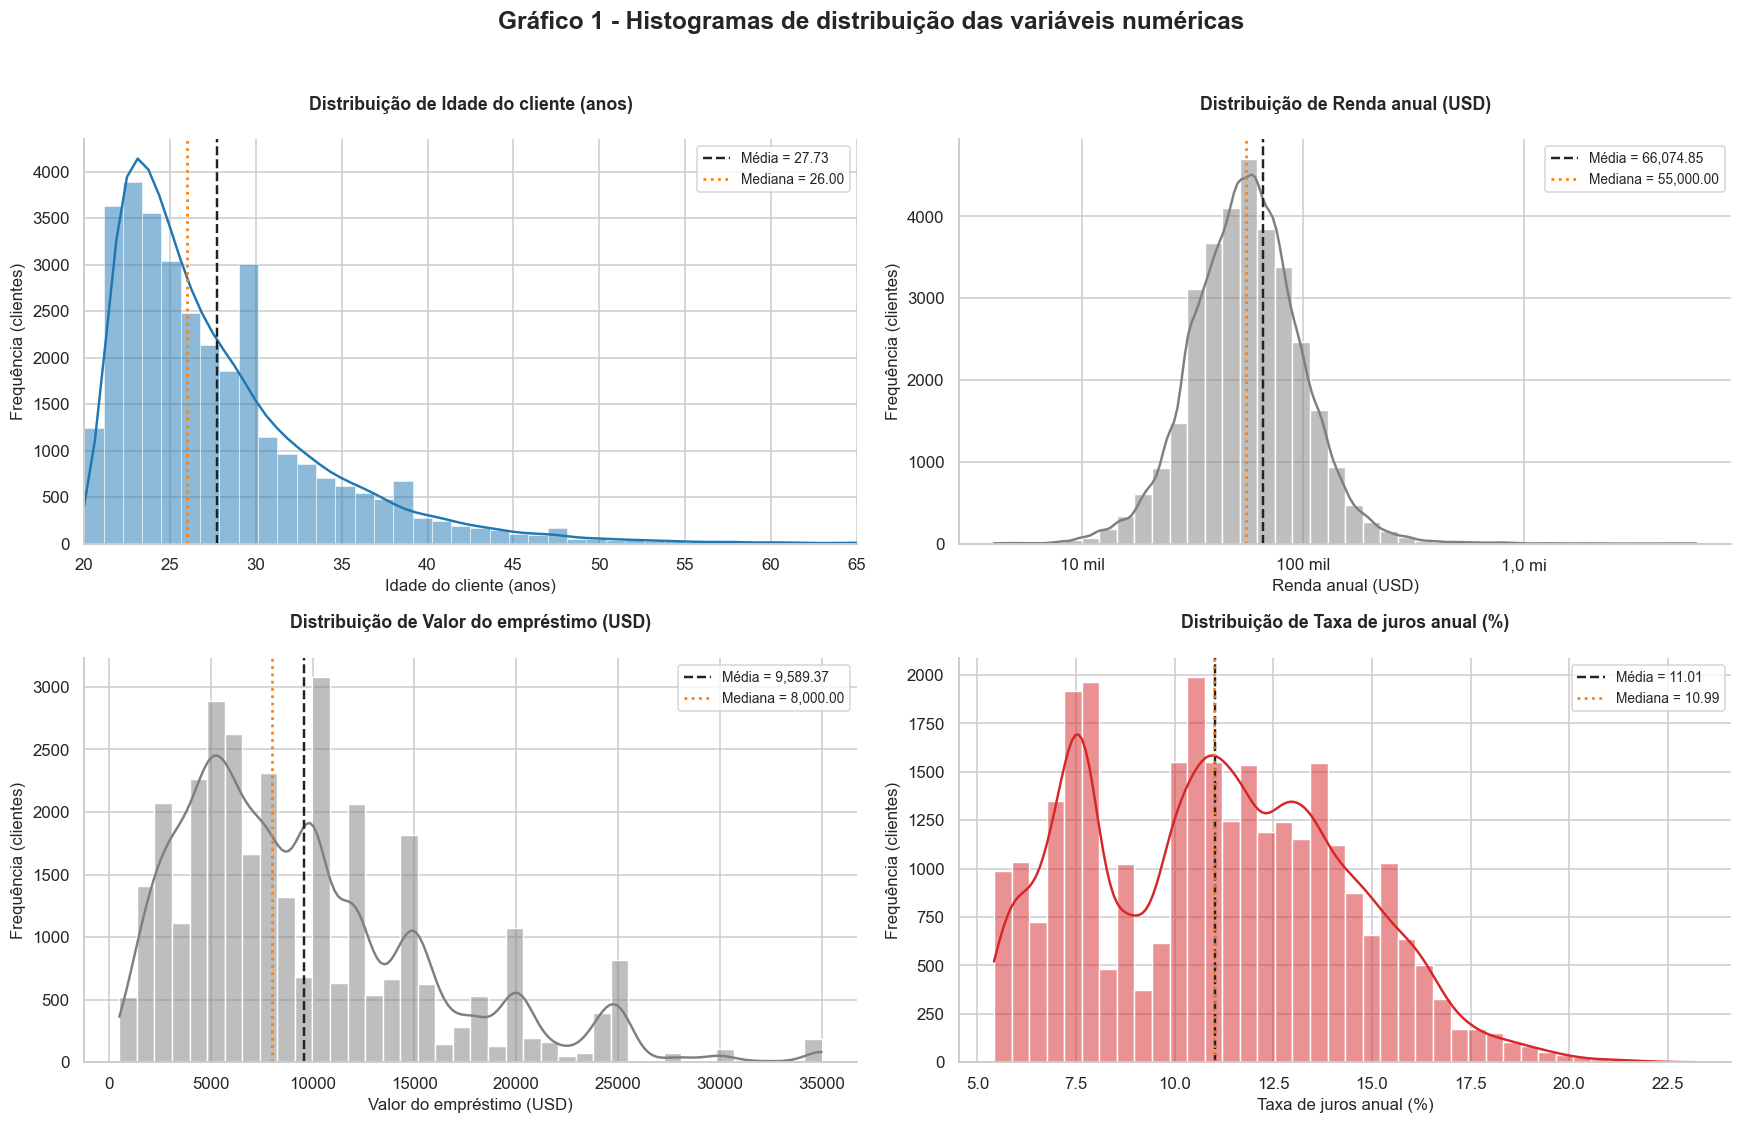

In [10]:
# =============================================================================
# GRÁFICO 1: HISTOGRAMAS DE DISTRIBUIÇÃO (IDADE E PRINCIPAIS VALORES)
# =============================================================================

config_histograma = [
    # (coluna, rótulo, cor, tratamento do eixo)
    ('person_age', 'Idade do cliente (anos)', COR_SEM_DEFAULT, 'janela'),
    ('person_income', 'Renda anual (USD)', COR_NEUTRA, 'log'),
    ('loan_amnt', 'Valor do empréstimo (USD)', COR_NEUTRA, 'linear'),
    ('loan_int_rate', 'Taxa de juros anual (%)', COR_COM_DEFAULT, 'linear'),
]

# Percentual da base que a janela de leitura da idade deve abranger:
PERCENTUAL_NA_JANELA = 99.8


def formatar_moeda_log(valor, posicao):
    """Escreve de forma compacta os ticks do eixo logarítmico (10 mil, 1,5 mi)."""
    if valor >= 1_000_000:
        return '{} mi'.format(padrao_br(valor / 1_000_000, 1))
    if valor >= 1_000:
        return '{} mil'.format(padrao_br(valor / 1_000))
    return padrao_br(valor)


fig, axes = plt.subplots(2, 2, figsize=(16, 10))

for ax, (coluna, rotulo, cor, tratamento) in zip(axes.flatten(), config_histograma):
    serie = df[coluna].dropna()

    if tratamento == 'log':
        # Com log_scale o próprio seaborn calcula os intervalos em espaço
        # logarítmico, então cada década ocupa a mesma largura e a renda deixa de
        # ficar prensada contra o eixo vertical.
        sns.histplot(
            data=df,
            x=coluna,
            bins=40,
            kde=True,
            log_scale=(True, False),
            color=cor,
            edgecolor='white',
            line_kws={'linewidth': 1.6, 'color': '#222222'},
            ax=ax,
        )
        ax.xaxis.set_major_formatter(FuncFormatter(formatar_moeda_log))
        ax.xaxis.set_minor_formatter(NullFormatter())

    else:
        # binrange recorta apenas a leitura do eixo, sem apagar nada da base.
        faixa = None
        if tratamento == 'janela':
            superior = np.ceil(np.percentile(serie, PERCENTUAL_NA_JANELA) / 5) * 5
            fora = int((serie > superior).sum())
            faixa = (float(serie.min()), float(superior))

        sns.histplot(
            data=df,
            x=coluna,
            bins=40,
            kde=True,
            binrange=faixa,
            color=cor,
            edgecolor='white',
            line_kws={'linewidth': 1.6, 'color': '#222222'},
            ax=ax,
        )
        if faixa is not None:
            ax.set_xlim(*faixa)

    media = serie.mean()
    mediana = serie.median()
    ax.axvline(media, color='#222222', linestyle='--', linewidth=1.6, label='Média = {:,.2f}'.format(media))
    ax.axvline(mediana, color='#FF7F0E', linestyle=':', linewidth=1.8, label='Mediana = {:,.2f}'.format(mediana))
    ax.set_title(f'Distribuição de {rotulo}\n', fontsize=11.5)
    ax.set_xlabel(rotulo)
    ax.set_ylabel('Frequência (clientes)')
    ax.legend(loc='upper right', fontsize=9)

fig.suptitle('Gráfico 1 - Histogramas de distribuição das variáveis numéricas', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


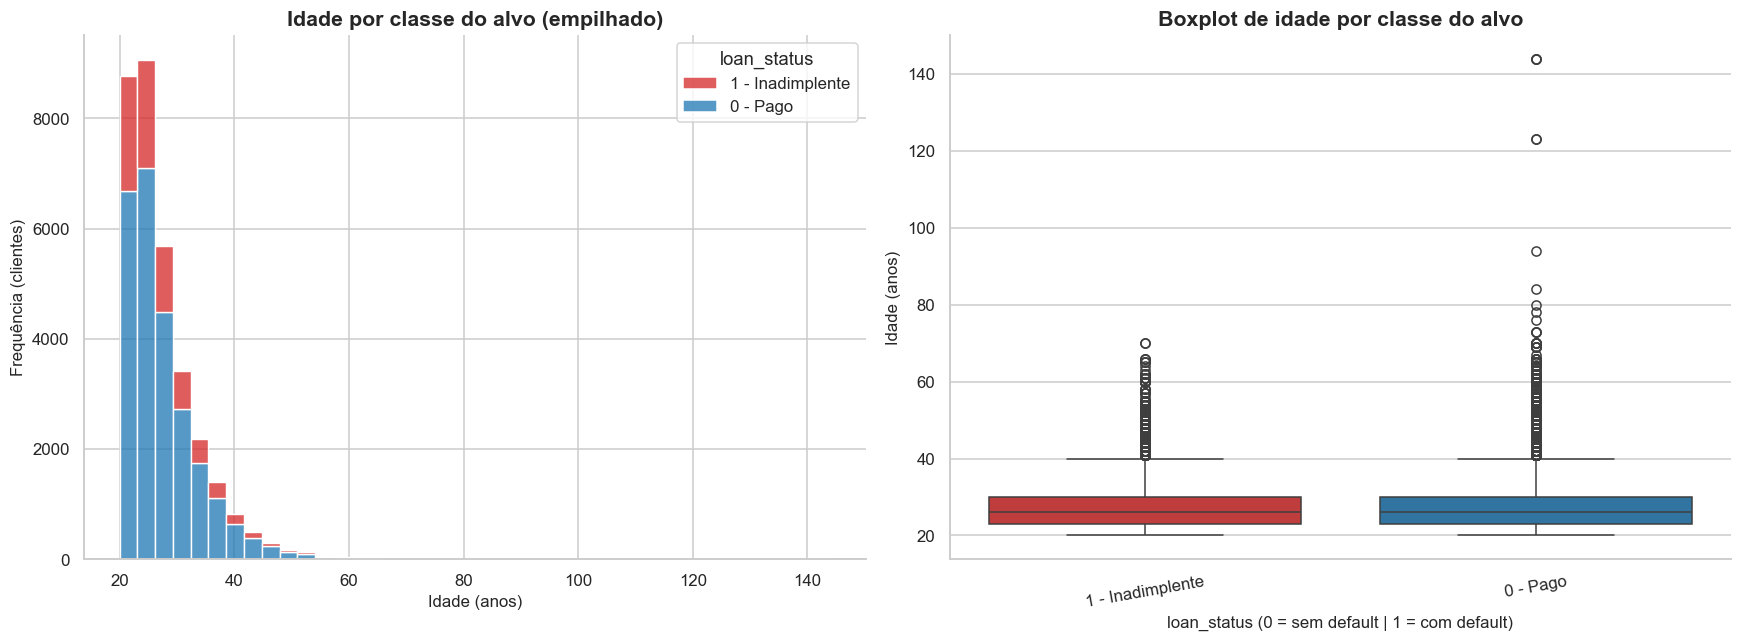

In [11]:
# =============================================================================
# DISTRIBUIÇÃO DA IDADE POR CLASSE DA VARIÁVEL ALVO
# =============================================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

sns.histplot(
    data=df,
    x='person_age',
    hue=COLUNA_ALVO_ROTULO,
    bins=40,
    multiple='stack',
    palette=PALETA_ALVO,
    ax=ax1,
)
ax1.set_title('Idade por classe do alvo (empilhado)')
ax1.set_xlabel('Idade (anos)')
ax1.set_ylabel('Frequência (clientes)')
ax1.legend_.set_title('loan_status')

sns.boxplot(
    data=df,
    x=COLUNA_ALVO_ROTULO,
    y='person_age',
    hue=COLUNA_ALVO_ROTULO,
    palette=PALETA_ALVO,
    legend=False,
    ax=ax2,
)
ax2.set_title('Boxplot de idade por classe do alvo')
ax2.set_xlabel('loan_status (0 = sem default | 1 = com default)')
ax2.set_ylabel('Idade (anos)')
ax2.tick_params(axis='x', labelrotation=10)
plt.tight_layout()
plt.show()

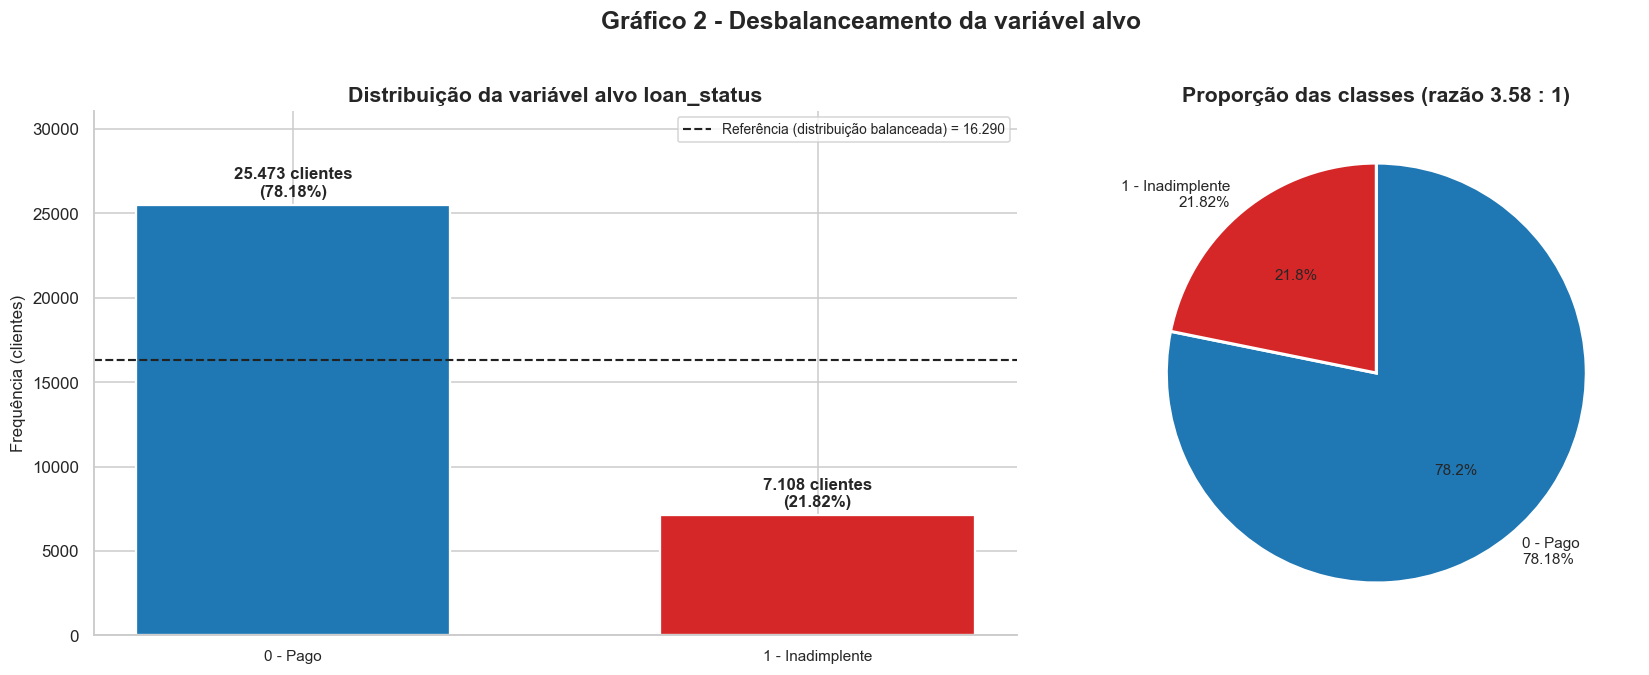

--------------------------------------------------------------
EVIDÊNCIA DO DESBALANCEAMENTO
--------------------------------------------------------------
0 - Pago                               25.473 clientes  ( 78.18%)
1 - Inadimplente                        7.108 clientes  ( 21.82%)
--------------------------------------------------------------
Classe majoritária / minoritária: 3.58 para 1
Diferença absoluta entre as classes: 18.365 clientes
--------------------------------------------------------------


In [12]:
# =============================================================================
# GRÁFICO 2: DESBALANCEAMENTO DA VARIÁVEL ALVO (loan_status)
# =============================================================================
contagem = df[TARGET].value_counts().sort_index()
percentual = (contagem / contagem.sum() * 100).round(2)
razao = contagem.max() / contagem.min()
indices = np.arange(len(contagem))
cores = [COR_SEM_DEFAULT, COR_COM_DEFAULT]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6), gridspec_kw={'width_ratios': [1.3, 1]})

barras = ax1.bar(indices, contagem.values, color=cores, edgecolor='white', linewidth=1.5, width=0.6)

for barra, cont, pct in zip(barras, contagem.values, percentual.values):
    ax1.text(barra.get_x() + barra.get_width() / 2, barra.get_height() + 350,
             f'{padrao_br(cont)} clientes\n({pct:.2f}%)',
             ha='center', va='bottom', fontsize=11, fontweight='bold')
    
ax1.set_xticks(indices)
ax1.set_xticklabels([ROTULO_TARGET[i] for i in contagem.index], fontsize=10)
ax1.set_title('Distribuição da variável alvo loan_status')
ax1.set_ylabel('Frequência (clientes)')
ax1.set_ylim(0, contagem.max() * 1.22)
ax1.axhline(contagem.mean(), color='#222222', linestyle='--', linewidth=1.4,
            label=f'Referência (distribuição balanceada) = {padrao_br(contagem.mean())}')
ax1.legend(loc='upper right', fontsize=9)

ax2.pie(
    contagem.values,
    labels=[f'{ROTULO_TARGET[i]}\n{percentual[i]:.2f}%' for i in contagem.index],
    colors=cores,
    autopct='%1.1f%%',
    startangle=90,
    counterclock=False,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2},
    textprops={'fontsize': 10},
)

ax2.set_title(f'Proporção das classes (razão {razao:.2f} : 1)')

fig.suptitle('Gráfico 2 - Desbalanceamento da variável alvo', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(LIN)
print('EVIDÊNCIA DO DESBALANCEAMENTO')
print(LIN)
for classe, cont in contagem.items():
    print(f'{ROTULO_TARGET[classe]:<34} {padrao_br(cont):>10} clientes  ({percentual[classe]:>6.2f}%)')
print(LIN)
print(f'Classe majoritária / minoritária: {razao:.2f} para 1')
print(f'Diferença absoluta entre as classes: {padrao_br(contagem.max() - contagem.min())} clientes')
print(LIN)

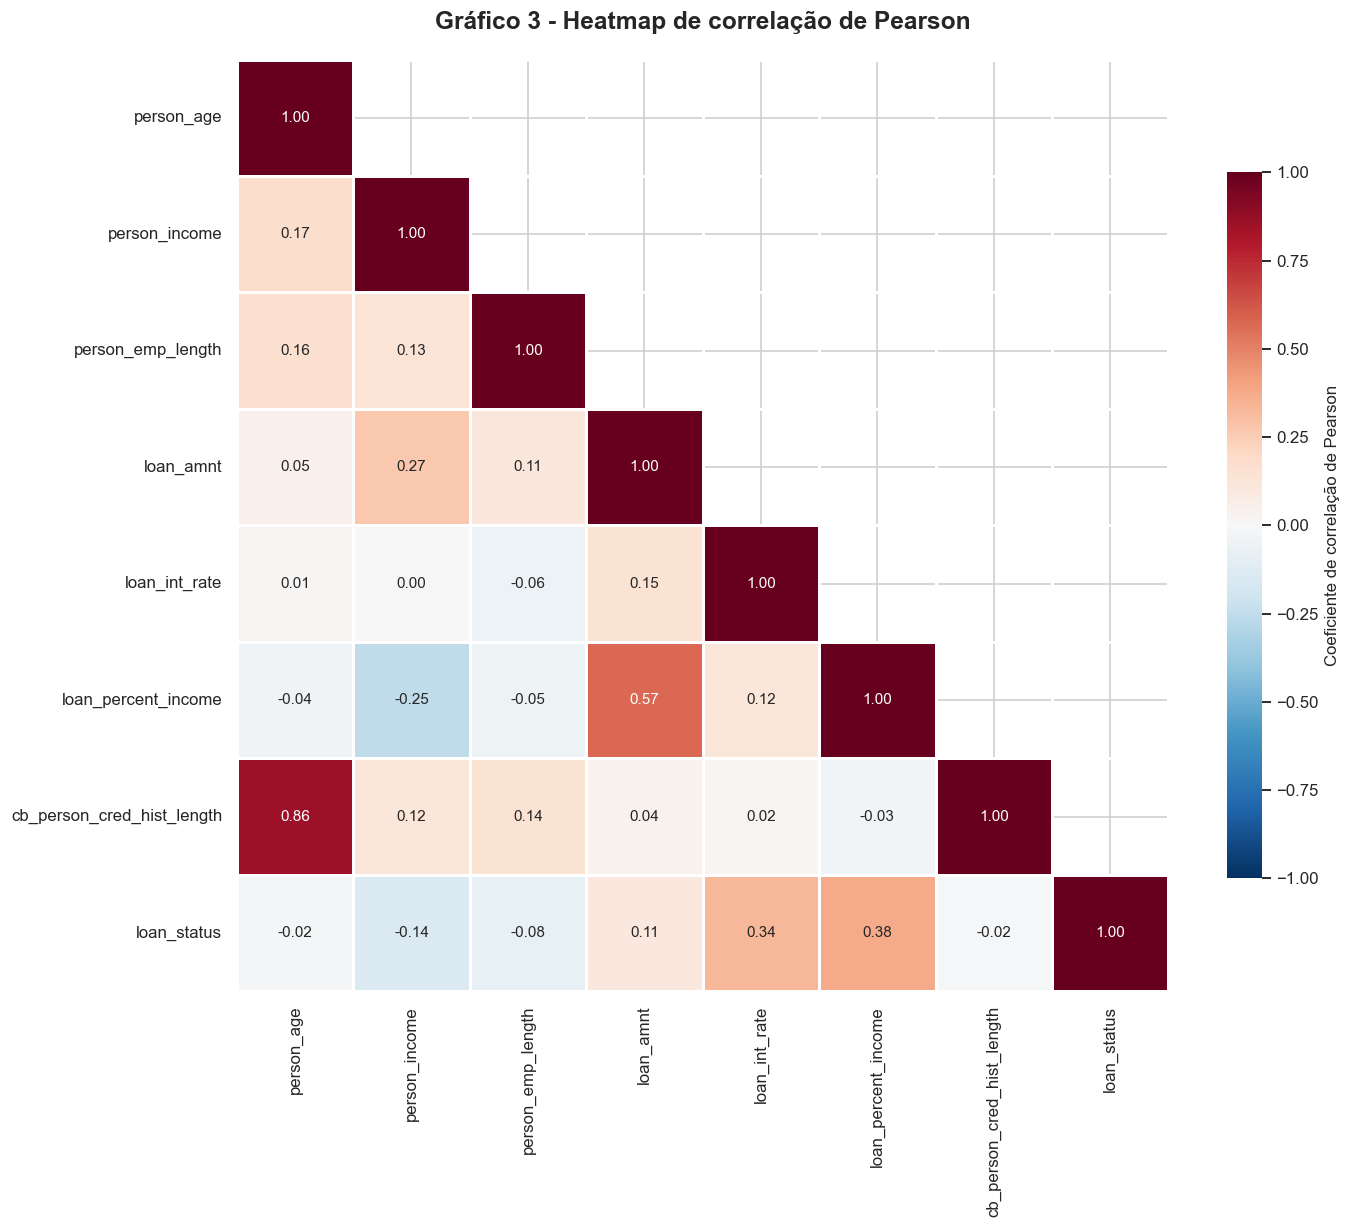

In [13]:
# =============================================================================
# GRÁFICO 3: HEATMAP DE CORRELAÇÃO DE PEARSON
# =============================================================================
colunas_correlacao = COLUNAS_NUMERICAS + [TARGET]
matriz_correlacao = df[colunas_correlacao].corr(method='pearson')

mascara_triangular = np.triu(np.ones_like(matriz_correlacao, dtype=bool), k=1)

fig, ax = plt.subplots(figsize=(13, 11))
sns.heatmap(
    matriz_correlacao,
    mask=mascara_triangular,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.8,
    linecolor='white',
    cbar_kws={'label': 'Coeficiente de correlação de Pearson', 'shrink': 0.75},
    annot_kws={'fontsize': 10},
    ax=ax,
)
ax.set_title('Gráfico 3 - Heatmap de correlação de Pearson', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

In [14]:
# =============================================================================
# RANKING DAS CORRELAÇÕES COM A VARIÁVEL ALVO
# =============================================================================
correlacoes_alvo = matriz_correlacao[TARGET].drop(TARGET).sort_values(key=abs, ascending=False)
tabela_correlacoes = pd.DataFrame({
    'Variável': correlacoes_alvo.index,
    'Descrição': [DICIONARIO_COLUNAS.get(c, '-') for c in correlacoes_alvo.index],
    'Correlação com loan_status': correlacoes_alvo.values.round(4),
    'Intensidade': correlacoes_alvo.abs().map(
        lambda v: 'forte' if v >= 0.5 else ('moderada' if v >= 0.3 else 'fraca')
    ),
    'Sinal': correlacoes_alvo.map(lambda v: 'positivo' if v > 0 else 'negativo'),
})

print('--- MATRIZ DE CORRELAÇÃO DE PEARSON (TABELA) ---')
display(matriz_correlacao.round(3))

print('--- CORRELAÇÕES ORDENADAS COM A VARIÁVEL ALVO ---')
display(tabela_correlacoes)

--- MATRIZ DE CORRELAÇÃO DE PEARSON (TABELA) ---


,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,loan_status
person_age,1.000,0.173,0.163,0.051,0.013,-0.042,0.859,-0.022
person_income,0.173,1.000,0.134,0.267,0.001,-0.254,0.118,-0.144
person_emp_length,0.163,0.134,1.000,0.113,-0.056,-0.054,0.145,-0.082
loan_amnt,0.051,0.267,0.113,1.000,0.147,0.573,0.042,0.105
loan_int_rate,0.013,0.001,-0.056,0.147,1.000,0.120,0.017,0.335
loan_percent_income,-0.042,-0.254,-0.054,0.573,0.120,1.000,-0.032,0.379
cb_person_cred_hist_length,0.859,0.118,0.145,0.042,0.017,-0.032,1.000,-0.016
loan_status,-0.022,-0.144,-0.082,0.105,0.335,0.379,-0.016,1.000


--- CORRELAÇÕES ORDENADAS COM A VARIÁVEL ALVO ---


,Variável,Descrição,Correlação com loan_status,Intensidade,Sinal
loan_percent_income,loan_percent_income,Percentual da renda comprometida (percent),0.3794,moderada,positivo
loan_int_rate,loan_int_rate,Taxa de juros anual (%),0.3351,moderada,positivo
person_income,person_income,Renda anual do cliente (USD),-0.1444,fraca,negativo
loan_amnt,loan_amnt,Valor solicitado do empréstimo (USD),0.1054,fraca,positivo
person_emp_length,person_emp_length,Tempo de estabilidade no emprego (anos),-0.0825,fraca,negativo
person_age,person_age,Idade do cliente (anos),-0.0216,fraca,negativo
cb_person_cred_hist_length,cb_person_cred_hist_length,Tamanho do histórico de crédito (anos),-0.0155,fraca,negativo


# Análise interpretativa dos dados

O dataset possui 32.581 registros e 12 variáveis, com apenas 1,03% de células nulas, concentradas principalmente em loan_int_rate (9,56%) e person_emp_length (2,75%). Apesar de relativamente completo, apresenta problemas de qualidade: person_income possui assimetria extrema (32,86), enquanto person_age e person_emp_length apresentam valores impossíveis (144 e 123 anos).

As maiores correlações com loan_status são loan_percent_income (r = 0,379) e loan_int_rate (r = 0,335). Há forte multicolinearidade entre person_age e cb_person_cred_hist_length (r = 0,859) e correlação moderada entre loan_amount e loan_percent_income (r = 0,573). O alvo apresenta desbalanceamento moderado, com 25.473 casos pagos e 7.108 inadimplentes (3,58:1), além de categorias raras que exigem cuidado no encoding. Foram identificadas 165 duplicatas.

Diante disso, a estratégia na preparação dos dados será:

1. Imputar loan_int_rate e person_emp_length, considerando indicadores de ausência.
 
2. Aplicar One Hot Encoding com handle_unknown='ignore' para categorias raras;

3. Aplicar limites plausíveis às variáveis com valores impossíveis.

4. Remover duplicatas;

5. Padronizar variáveis numéricas e testar transformações robustas/logarítmicas em person_income.

6. Priorizar loan_percent_income, loan_int_rate e variáveis categóricas de risco, tratando redundâncias.

7. Considerar ponderação de classes ou reamostragem e avaliar Recall, F1 e as matrizes de confusão, evitando depender apenas da acurácia.

8. Executar imputação, tratamento de outliers e escalonamento exclusivamente sobre os dados de treino para evitar vazamento de dados.

# FASE 2: Tratamento e Limpeza dos Dados (Data Prep)

In [15]:
# =============================================================================
# REMOÇÃO DE LINHAS DUPLICADAS
# =============================================================================
# A base original é preservada em memória para permitir comparações antes/depois e para
# quantificar o impacto de cada tratamento no volume de amostras.
base_original = df.copy()
linhas_antes = base_original.shape[0]
inadimplentes_antes = int(base_original[TARGET].sum())

# O critério de duplicata considera todas as colunas da base, incluindo o alvo: um
# cliente repetido com o mesmo perfil e o mesmo desfechamento é de fato redundante.
duplicadas_completas = int(base_original[COLUNAS_BASE].duplicated().sum())
duplicadas_sem_alvo = int(base_original.drop(columns=[TARGET]).duplicated().sum())
duplicadas_classe = base_original.loc[base_original[COLUNAS_BASE].duplicated(), TARGET].value_counts()

df = base_original.drop_duplicates(subset=COLUNAS_BASE).reset_index(drop=True)

print(BAR)
print('DIAGNÓSTICO E REMOÇÃO DE LINHAS DUPLICADAS')
print(BAR)
print(f'Linhas na base original ...........................: {padrao_br(linhas_antes)}')
print(f'Duplicadas completas ................: {padrao_br(duplicadas_completas)}')
print(f'Linhas efetivamente removidas ......................: {padrao_br(linhas_antes - df.shape[0])}')
print(f'Linhas na base deduplicada ........................: {padrao_br(df.shape[0])}')
print(f'Regressão de volume ...............................: {padrao_br((linhas_antes - df.shape[0]) / linhas_antes * 100, 2)}%')
print(LIN)
print(f'Inadimplentes (classe 1) antes / depois ............: {padrao_br(inadimplentes_antes)} -> {padrao_br(int(df[TARGET].sum()))}')
print(f'Regressão da classe minoritária ...................: {padrao_br((inadimplentes_antes - int(df[TARGET].sum())) / inadimplentes_antes * 100, 2)}%')
print(f'Proporção de inadimplentes antes / depois .........: {base_original[TARGET].mean() * 100:.2f}% -> {df[TARGET].mean() * 100:.2f}%')
print(LIN)
print('Composição das linhas removidas por classe do alvo:')
for classe, quantidade in duplicadas_classe.items():
    print(f'    {ROTULO_TARGET[classe]:<24} {padrao_br(quantidade):>5} registros')
print(BAR)
print('As duplicatas se concentram na classe majoritária, de modo que a remoção remove')
print(f'{padrao_br((linhas_antes - df.shape[0]) / linhas_antes * 100, 2)}% do volume e não enviesa a leitura do desbalanceamento da Fase 1.')

DIAGNÓSTICO E REMOÇÃO DE LINHAS DUPLICADAS
Linhas na base original ...........................: 32.581
Duplicadas completas ................: 165
Linhas efetivamente removidas ......................: 165
Linhas na base deduplicada ........................: 32.416
Regressão de volume ...............................: 0,51%
--------------------------------------------------------------
Inadimplentes (classe 1) antes / depois ............: 7.108 -> 7.089
Regressão da classe minoritária ...................: 0,27%
Proporção de inadimplentes antes / depois .........: 21.82% -> 21.87%
--------------------------------------------------------------
Composição das linhas removidas por classe do alvo:
    0 - Pago                   146 registros
    1 - Inadimplente            19 registros
As duplicatas se concentram na classe majoritária, de modo que a remoção remove
0,51% do volume e não enviesa a leitura do desbalanceamento da Fase 1.


In [16]:
# =============================================================================
# AJUSTE DOS LIMITES DE DOMÍNIO (CLIPPING / CAPPING)
# =============================================================================
# Corrigir primeiro os valores impossíveis, garantindo que as estatísticas
# de imputação sejam calculadas sobre dados válidos. Preservar outliers legítimos
# das demais variáveis para não reduzir a amostra.
base_antes_limites = df.copy()

registros_limites = []
for coluna, (minimo, maximo) in LIMITES_DOMINIO.items():
    serie_original = base_antes_limites[coluna]
    fora = (serie_original < minimo) | (serie_original > maximo)
    registros_limites.append({
        'Variável': coluna,
        'Limite mínimo': minimo,
        'Limite máximo': maximo,
        'Valor original mínimo': serie_original.min(),
        'Valor original máximo': serie_original.max(),
        'Registros afetados': int(fora.sum()),
        '% da base': round(fora.mean() * 100, 2),
    })
    df[coluna] = df[coluna].clip(lower=minimo, upper=maximo)
tabela_limites = pd.DataFrame(registros_limites)

print('--- VALORES AJUSTADOS AOS LIMITES DE DOMÍNIO ---')
display(tabela_limites)

print('--- VERIFICAÇÃO DOS LIMITES DE DOMÍNIO ---')
for coluna, (minimo, maximo) in LIMITES_DOMINIO.items():
    print(f'{coluna:<28} mínimo = {padrao_br(df[coluna].min(), 2):>8} | máximo = {padrao_br(df[coluna].max(), 2):>8}')
print(f'Células nulas preservadas para a imputação .....: {padrao_br(int(df[COLUNAS_BASE].isna().sum().sum()))}')
print(BAR)
print('Nenhuma linha foi removida: somente os valores impossíveis foram ajustados aos')
print('limites plausíveis, e as caudas legítimas da distribuição foram preservadas.')
print(BAR)


--- VALORES AJUSTADOS AOS LIMITES DE DOMÍNIO ---


,Variável,Limite mínimo,Limite máximo,Valor original mínimo,Valor original máximo,Registros afetados,% da base
0,person_age,18,100,20.0,144.0,5,0.02
1,person_emp_length,0,60,0.0,123.0,2,0.01
2,cb_person_cred_hist_length,0,60,2.0,30.0,0,0.00


--- VERIFICAÇÃO DOS LIMITES DE DOMÍNIO ---
person_age                   mínimo =    20,00 | máximo =   100,00
person_emp_length            mínimo =     0,00 | máximo =    60,00
cb_person_cred_hist_length   mínimo =     2,00 | máximo =    30,00
Células nulas preservadas para a imputação .....: 3.982
Nenhuma linha foi removida: somente os valores impossíveis foram ajustados aos
limites plausíveis, e as caudas legítimas da distribuição foram preservadas.


In [17]:
# =============================================================================
# SEPARAÇÃO ESTRATIFICADA ANTECIPADA (ANTES DA IMPUTAÇÃO)
# =============================================================================
# Somente os índices são sorteados aqui. As features, o encoding e o balanceamento são
# montados mais adiante, reaproveitando exatamente esta separação, sem novo sorteio.

INDICES_TREINO, INDICES_TESTE = train_test_split(
    df.index,
    test_size=0.20,
    stratify=df[TARGET],
    random_state=SEMENTE,
)

# Recortes da base em treino e teste, usados no diagnóstico da imputação.
base_treino = df.loc[INDICES_TREINO]
base_teste = df.loc[INDICES_TESTE]

print(BAR)
print('SEPARAÇÃO ESTRATIFICADA ANTECIPADA')
print(BAR)
print(f'Amostras de treino ..............................: {padrao_br(len(base_treino))}')
print(f'Amostras de teste ...............................: {padrao_br(len(base_teste))}')
print(f'Divisão nominal ..................................: 80,00% / 20,00%')
print(LIN)
print(f'Inadimplentes no treino ...............: {padrao_br(int(base_treino[TARGET].sum()))} ({base_treino[TARGET].mean() * 100:.2f}%)')
print(f'Inadimplentes no teste ..................: {padrao_br(int(base_teste[TARGET].sum()))} ({base_teste[TARGET].mean() * 100:.2f}%)')
print(LIN)
print('O stratify=y garante que a proporção de inadimplentes seja praticamente')
print('idêntica nas duas bases, de modo que uma base não herda uma distribuição')
print('diferente da outra por puro acaso do sorteio.')
print(BAR)

SEPARAÇÃO ESTRATIFICADA ANTECIPADA
Amostras de treino ..............................: 25.932
Amostras de teste ...............................: 6.484
Divisão nominal ..................................: 80,00% / 20,00%
--------------------------------------------------------------
Inadimplentes no treino ...............: 5.671 (21.87%)
Inadimplentes no teste ..................: 1.418 (21.87%)
--------------------------------------------------------------
O stratify=y garante que a proporção de inadimplentes seja praticamente
idêntica nas duas bases, de modo que uma base não herda uma distribuição
diferente da outra por puro acaso do sorteio.


In [ ]:
# =============================================================================
# TRATAMENTO DE VALORES NULOS (IMPUTAÇÃO)
# =============================================================================
# O diagnóstico é medido na amostra de treino porque é de lá que saem os parâmetros da
# imputação.A média e a mediana que serão aplicadas ao teste são exatamente as do treino.

faltantes = pd.DataFrame({
    'Variável': COLUNAS_BASE,
    'Descrição': [DICIONARIO_COLUNAS.get(c, '-') for c in COLUNAS_BASE],
    'Qtd faltantes': base_treino[COLUNAS_BASE].isna().sum().values,
    '% faltantes': (base_treino[COLUNAS_BASE].isna().mean().values * 100).round(2),
    'Média': base_treino[COLUNAS_BASE].mean(numeric_only=True).reindex(COLUNAS_BASE).values.round(2),
    'Mediana': base_treino[COLUNAS_BASE].median(numeric_only=True).reindex(COLUNAS_BASE).values.round(2),
    'Assimetria': base_treino[COLUNAS_NUMERICAS + [TARGET]].skew().reindex(COLUNAS_BASE).values.round(2),
    'Outliers IQR': [contar_outliers(base_treino[c]) if pd.api.types.is_numeric_dtype(base_treino[c]) else 0 for c in COLUNAS_BASE],
})
faltantes = faltantes[faltantes['Qtd faltantes'] > 0].sort_values('Qtd faltantes', ascending=False)

print('--- COLUNAS COM DADOS AUSENTES NA AMOSTRA DE TREINO ---')
display(faltantes)

print('--- AS MESMAS COLUNAS NA BASE INTEIRA, PARA COMPARAR ---')
faltantes_base = pd.DataFrame({
    'Variável': COLUNAS_BASE,
    'Qtd faltantes': df[COLUNAS_BASE].isna().sum().values,
    '% faltantes': (df[COLUNAS_BASE].isna().mean().values * 100).round(2),
})
display(faltantes_base[faltantes_base['Qtd faltantes'] > 0].sort_values('Qtd faltantes', ascending=False))

print('--- JUSTIFICATIVA DA TÉCNICA DE IMPUTAÇÃO: MÉDIA vs MEDIANA ---')
for _, linha in faltantes.iterrows():
    print(f"{linha['Variável']}  ({linha['Descrição']})")
    print(f"    ausências .....: {padrao_br(linha['Qtd faltantes'])} ({padrao_br(linha['% faltantes'], 2)}% do treino)")
    print(f"    média .........: {padrao_br(linha['Média'], 2)}")
    print(f"    mediana .......: {padrao_br(linha['Mediana'], 2)}")
    print(f"    assimetria ....: {padrao_br(linha['Assimetria'], 2)}")
    print(f"    outliers IQR ..: {padrao_br(linha['Outliers IQR'])} registros")
    print(f"    decisão .......: imputação pela {TECNICA_IMPUTACAO[linha['Variável']]}")
print(BAR)

--- COLUNAS COM DADOS AUSENTES NA AMOSTRA DE TREINO ---


,Variável,Descrição,Qtd faltantes,% faltantes,Média,Mediana,Assimetria,Outliers IQR
4,loan_int_rate,Taxa de juros anual (%),2488,9.59,11.02,10.99,0.2,3
2,person_emp_length,Tempo de estabilidade no emprego (anos),727,2.80,4.76,4.00,1.4,669


--- AS MESMAS COLUNAS NA BASE INTEIRA, PARA COMPARAR ---


,Variável,Qtd faltantes,% faltantes
4,loan_int_rate,3095,9.55
2,person_emp_length,887,2.74


--- JUSTIFICATIVA DA TÉCNICA DE IMPUTAÇÃO: MÉDIA vs MEDIANA ---
loan_int_rate  (Taxa de juros anual (%))
    ausências .....: 2.488 (9,59% do treino)
    média .........: 11,02
    mediana .......: 10,99
    assimetria ....: 0,20
    outliers IQR ..: 3 registros
    decisão .......: imputação pela média
person_emp_length  (Tempo de estabilidade no emprego (anos))
    ausências .....: 727 (2,80% do treino)
    média .........: 4,76
    mediana .......: 4,00
    assimetria ....: 1,40
    outliers IQR ..: 669 registros
    decisão .......: imputação pela mediana


IMPUTAÇÃO PELA MÉDIA:

Distribuição praticamente simétrica (assimetria 0,20) e somente 3 registros fora
dos limites de Tukey na amostra de treino. Sem outliers relevantes, a média (11,02%)
é um estimador confiável da taxa de juros praticada no mercado e praticamente coincide
com a mediana (10,99%). Por ser a variável com maior volume de ausências (2.488
registros no treino, 3.095 na base inteira) e com relevante sinal preditivo
(r = +0,335), a ausência em si é preservada em indicador binário.

IMPUTAÇÃO PELA MEDIANA

Distribuição assimétrica à direita (assimetria 1,40). A cauda com 123 anos de
estabilidade já foi ajustada para o limite de domínio de 60 anos na etapa anterior, e
ainda assim a assimetria permanece relevante: 669 registros da amostra de treino
violam o limite superior de Tukey. A média é puxada por essa cauda e produziria um
tempo de emprego irreal nos registros preenchidos; a mediana (4 anos) não é afetada
por outliers e mantém o valor central da distribuição, como confirmado pelo
descasamento entre os dois estimadores (média 4,76 e mediana 4,00).

AMBAS AS ESTIMATIVAS VIERAM DA AMOSTRA DE TREINO

Nenhum desses números foi calculado com as linhas de teste. A média e a mediana
aplicadas ao teste são exatamente as do treino, e é essa separação que impede o modelo
de ser avaliado sobre uma estatística que ele já viu. É o mesmo princípio do
`StandardScaler` ajustado só no treino, aplicado um passo antes no pipeline.

In [19]:
# O indicador de ausência é criado ANTES da imputação, para que a informação
# "taxa de juros não informada" não se perca ao preencher o valor.
df['loan_int_rate_ausente'] = df['loan_int_rate'].isna().astype(int)

# Os parâmetros são estimados exclusivamente na amostra de treino e então aplicados às
# duas bases, exatamente como o StandardScaler e o OneHotEncoder farão mais adiante.
# Estimar a média com as linhas de teste contaminaria a medição da generalização.
IMPUTACAO = {
    'loan_int_rate': base_treino['loan_int_rate'].mean(),
    'person_emp_length': base_treino['person_emp_length'].median(),
}

for coluna, valor in IMPUTACAO.items():
    ausencias = int(df[coluna].isna().sum())
    df[coluna] = df[coluna].fillna(valor)
    print(f'{coluna:<20} {padrao_br(ausencias)} ausências preenchidas com {padrao_br(valor, 2)} ({TECNICA_IMPUTACAO[coluna]}, estimada no treino)')

print('--- VERIFICAÇÃO DOS NULOS APÓS A IMPUTAÇÃO ---')
print(f'Células nulas remanescentes .......................: {padrao_br(int(df[COLUNAS_BASE].isna().sum().sum()))}')
print(f'Regressão de volume pela imputação ...............: nenhuma linha excluída')
print(f'Indicador loan_int_rate_ausente = 1 ...............: {padrao_br(int(df["loan_int_rate_ausente"].sum()))} registros')

loan_int_rate        3.095 ausências preenchidas com 11,02 (média, estimada no treino)
person_emp_length    887 ausências preenchidas com 4,00 (mediana, estimada no treino)
--- VERIFICAÇÃO DOS NULOS APÓS A IMPUTAÇÃO ---
Células nulas remanescentes .......................: 0
Regressão de volume pela imputação ...............: nenhuma linha excluída
Indicador loan_int_rate_ausente = 1 ...............: 3.095 registros


--- DIAGNÓSTICO DE OUTLIERS PELA REGRA DE TURKEY (1,5 x IQR) ---


,Variável,Descrição,Mínimo,Q1,Q3,Máximo,Limite inferior,Limite superior,Qtd outliers,% outliers
0,person_age,Idade do cliente (anos),20.00,23.00,30.00,100.00,12.50,40.50,1491,4.60
1,person_income,Renda anual do cliente (USD),4000.00,38542.00,79218.00,6000000.00,-22472.00,140232.00,1478,4.56
2,person_emp_length,Tempo de estabilidade no emprego (anos),0.00,2.00,7.00,60.00,-5.50,14.50,852,2.63
3,loan_amnt,Valor solicitado do empréstimo (USD),500.00,5000.00,12250.00,35000.00,-5875.00,23125.00,1679,5.18
4,loan_int_rate,Taxa de juros anual (%),5.42,8.49,13.11,23.22,1.56,20.04,70,0.22
5,loan_percent_income,Percentual da renda comprometida (percent),0.00,0.09,0.23,0.83,-0.12,0.44,650,2.01
6,cb_person_cred_hist_length,Tamanho do histórico de crédito (anos),2.00,3.00,8.00,30.00,-4.50,15.50,1139,3.51


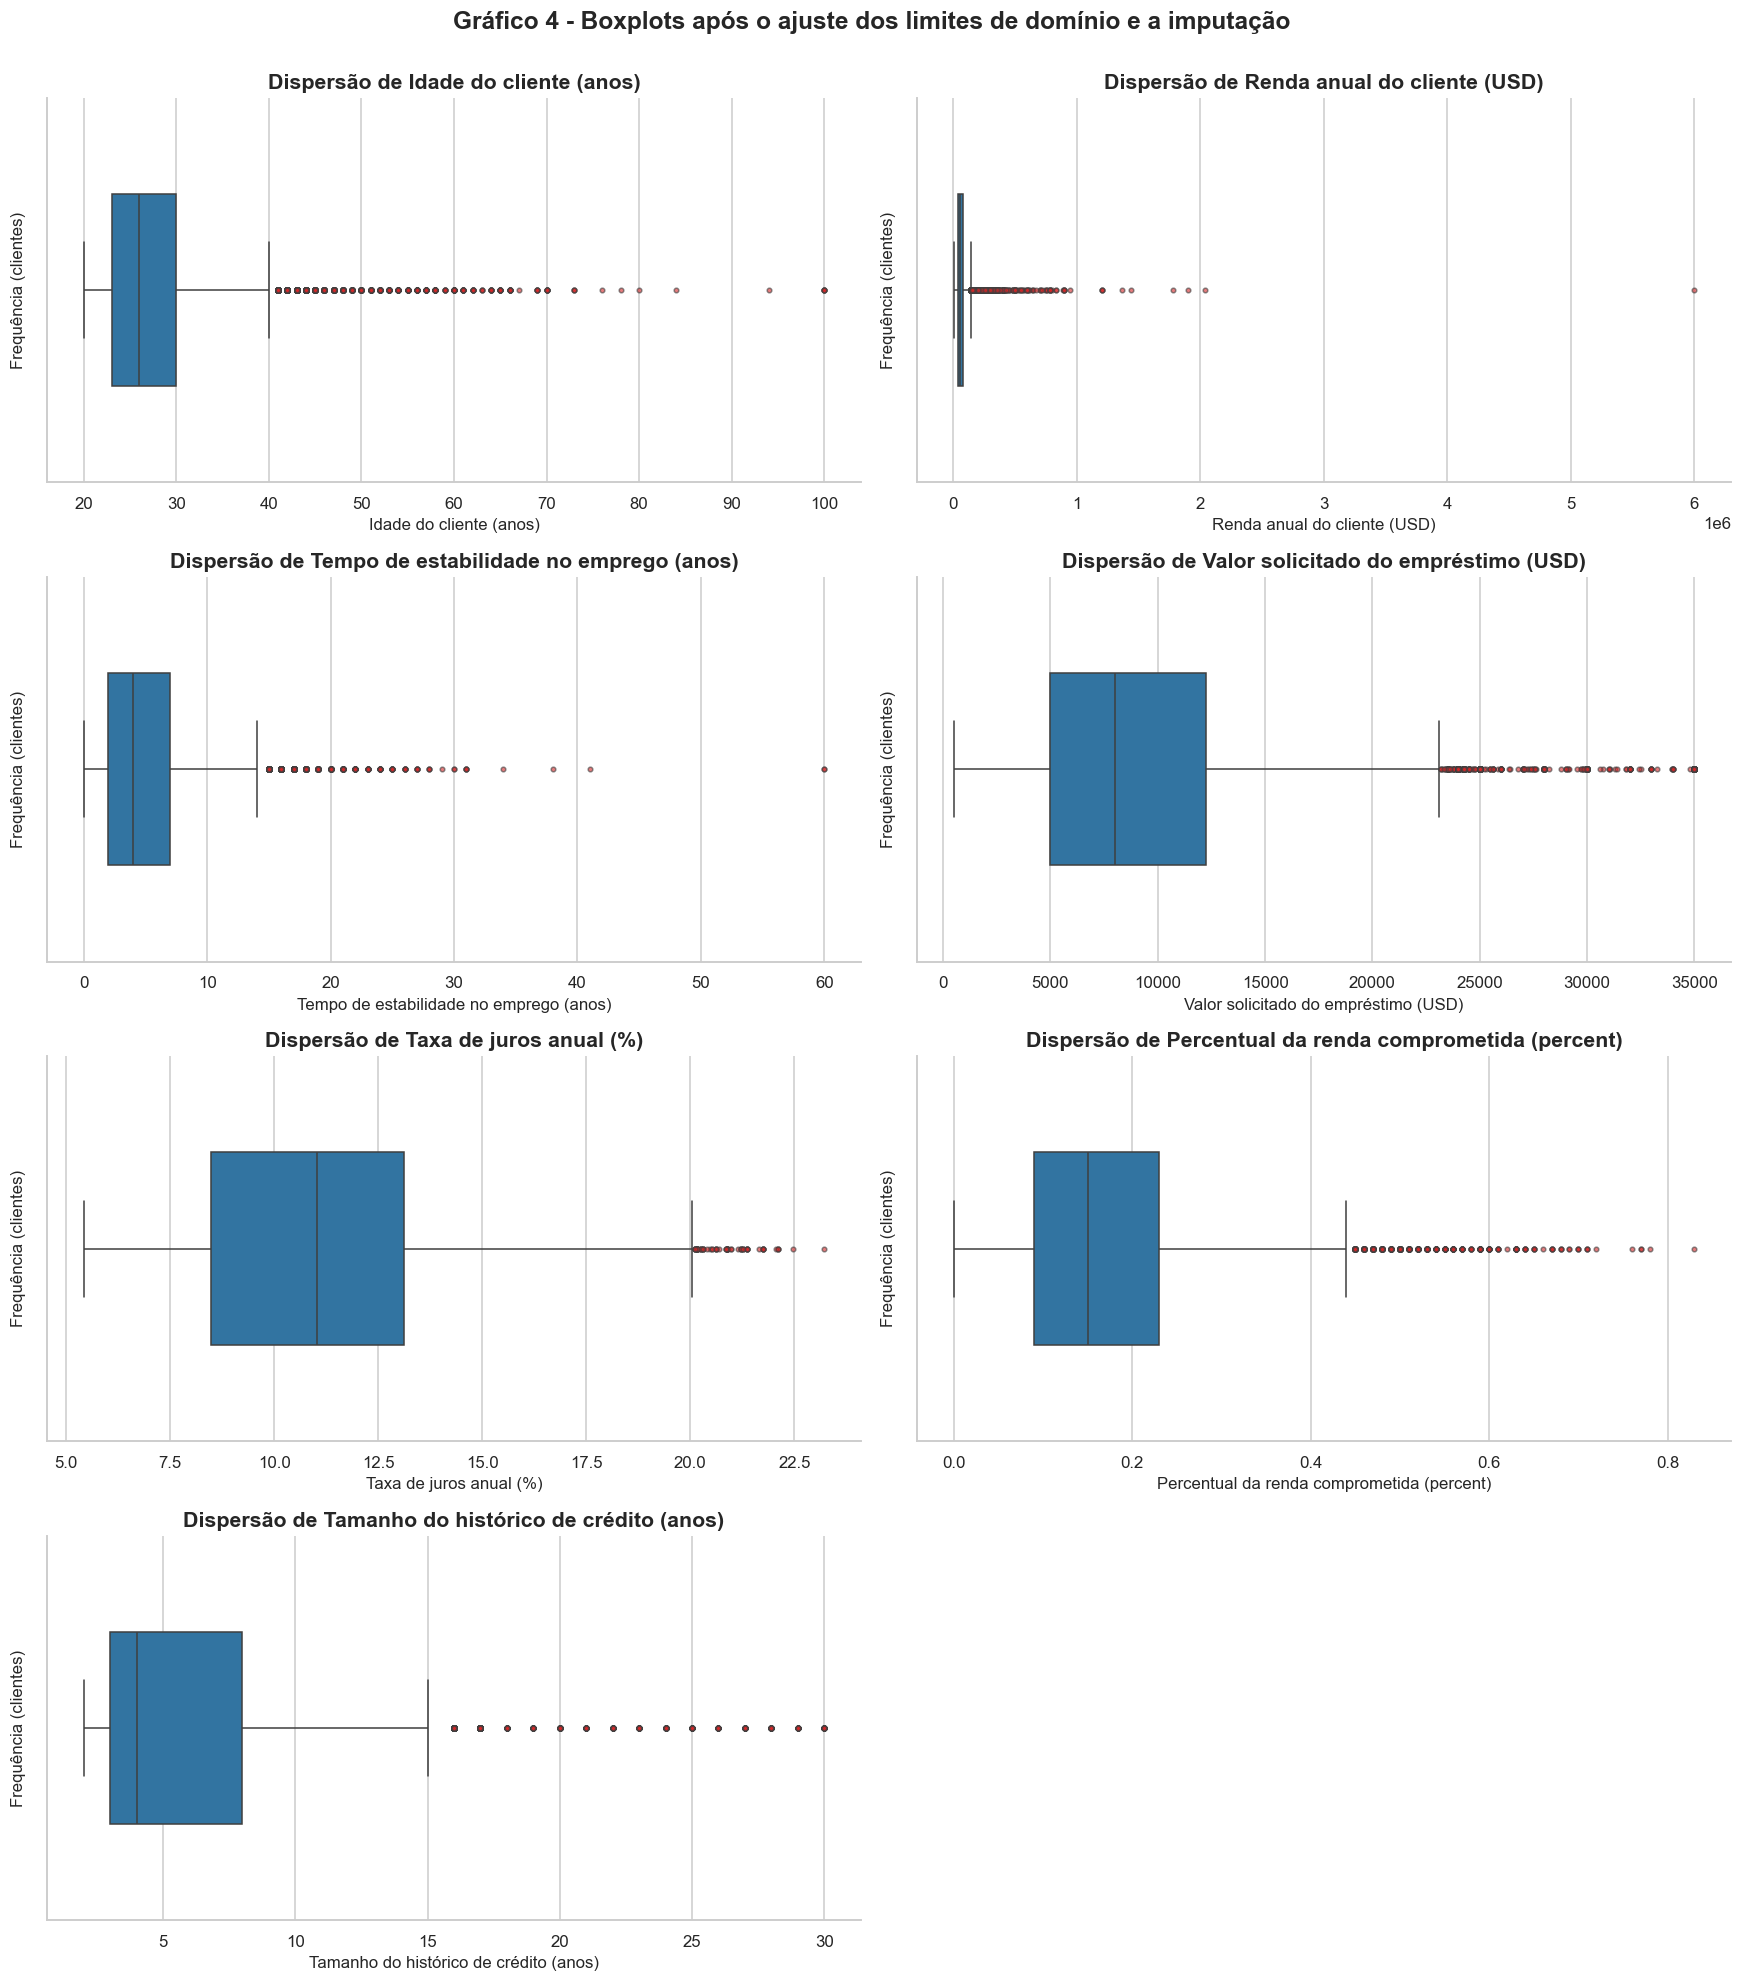

In [20]:
# =============================================================================
# DIAGNÓSTICO DE OUTLIERS PELA REGRA DE TURKEY (1,5 x IQR)
# =============================================================================
registros_outliers = []
for coluna in COLUNAS_NUMERICAS:
    serie = df[coluna]
    q1 = serie.quantile(0.25)
    q3 = serie.quantile(0.75)
    limite_inferior, limite_superior = limites_iqr(serie)
    fora = (serie < limite_inferior) | (serie > limite_superior)
    registros_outliers.append({
        'Variável': coluna,
        'Descrição': DICIONARIO_COLUNAS[coluna],
        'Mínimo': serie.min(),
        'Q1': q1,
        'Q3': q3,
        'Máximo': serie.max(),
        'Limite inferior': round(limite_inferior, 2),
        'Limite superior': round(limite_superior, 2),
        'Qtd outliers': int(fora.sum()),
        '% outliers': round(fora.mean() * 100, 2),
    })
tabela_outliers = pd.DataFrame(registros_outliers)

print('--- DIAGNÓSTICO DE OUTLIERS PELA REGRA DE TURKEY (1,5 x IQR) ---')
display(tabela_outliers)

fig, axes = plt.subplots(4, 2, figsize=(16, 18))
for ax, coluna in zip(axes.flatten(), COLUNAS_NUMERICAS):
    sns.boxplot(
        data=df,
        x=coluna,
        color=COR_SEM_DEFAULT,
        width=0.5,
        flierprops={'marker': 'o', 'markerfacecolor': COR_COM_DEFAULT, 'markersize': 3, 'alpha': 0.6},
        ax=ax,
    )
    ax.set_title(f'Dispersão de {DICIONARIO_COLUNAS[coluna]}')
    ax.set_xlabel(DICIONARIO_COLUNAS[coluna])
    ax.set_ylabel('Frequência (clientes)')
axes.flatten()[-1].set_visible(False)
fig.suptitle('Gráfico 4 - Boxplots após o ajuste dos limites de domínio e a imputação',
             fontsize=16, fontweight='bold', y=1.0)
plt.tight_layout()
plt.show()

A regra IQR é aplicada aqui somente como diagnóstico: nenhuma linha é removida. Os limites de domínio já foram ajustados na etapa anterior, de modo que os outliers restantes são extremos apenas do ponto de vista estatístico, mas plausíveis, e por isso são preservados. Outlier estatístico não é necessariamente erro de registro: em person_income, 1.478 registros acima do limite superior são clientes de alta renda legítimos, que pertencem à própria população de risco analisada.  

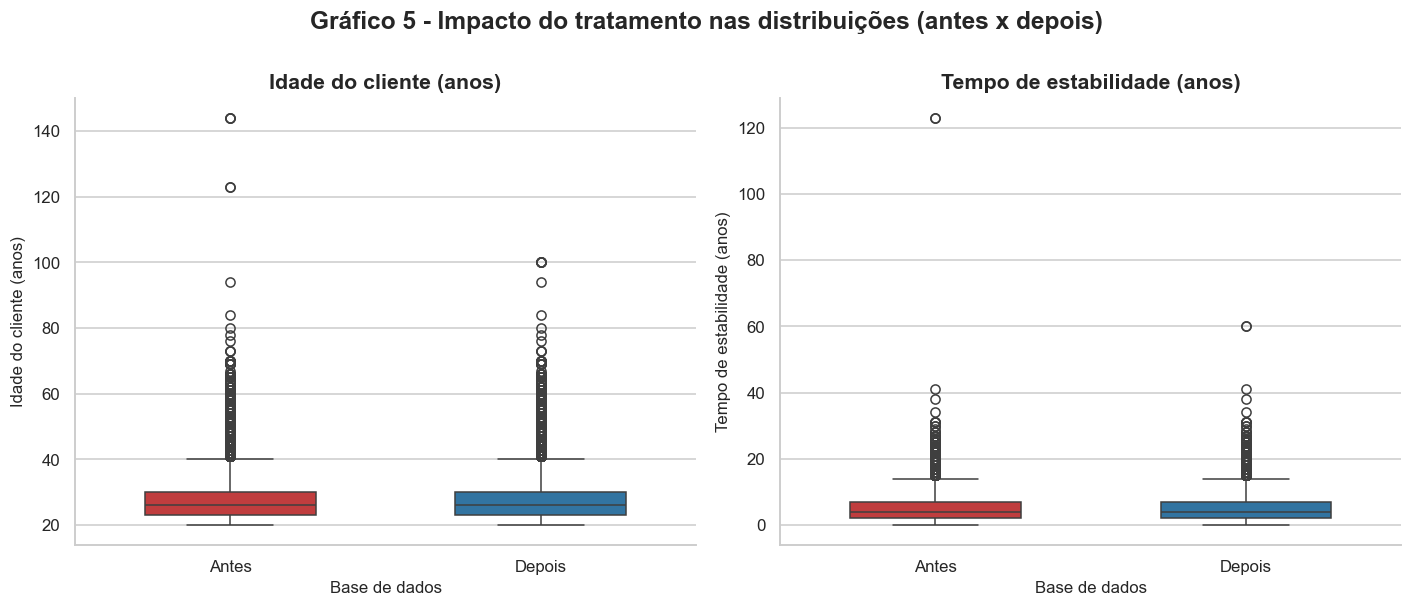

VALIDAÇÃO DA BASE TRATADA
Linhas ............................................: 32.416
Duplicadas remanescentes ...........................: 0
Células nulas remanescentes ........................: 0
Variáveis de modelagem ............................: 12 (11 preditoras + 1 alvo)
Colunas auxiliares ................................: 2 (loan_status_rotulo, loan_int_rate_ausente)
Inadimplentes .....................................: 7.089 (21.87%)
--------------------------------------------------------------


,count,mean,50%,max
person_age,32416.0,27.74,26.00,100.00
person_income,32416.0,66091.64,55000.00,6000000.00
person_emp_length,32416.0,4.76,4.00,60.00
loan_amnt,32416.0,9593.85,8000.00,35000.00
loan_int_rate,32416.0,11.02,11.02,23.22
loan_percent_income,32416.0,0.17,0.15,0.83
cb_person_cred_hist_length,32416.0,5.81,4.00,30.00


In [21]:
# =============================================================================
# ANÁLISE DO IMPACTO ESPERADO NOS MODELOS E VALIDAÇÃO FINAL DA BASE
# =============================================================================

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

comparacao_outliers = [
    ('person_age', 'Idade do cliente (anos)'),
    ('person_emp_length', 'Tempo de estabilidade (anos)'),
]
base_antes = base_original[COLUNAS_NUMERICAS].copy()
base_antes['base'] = 'Antes'
base_depois = df[COLUNAS_NUMERICAS].copy()
base_depois['base'] = 'Depois'
for ax, (coluna, rotulo) in zip(axes.flatten(), comparacao_outliers):
    sns.boxplot(
        data=pd.concat([base_antes, base_depois], ignore_index=True),
        x='base',
        y=coluna,
        order=['Antes', 'Depois'],
        hue='base',
        palette={'Antes': COR_COM_DEFAULT, 'Depois': COR_SEM_DEFAULT},
        legend=False,
        width=0.55,
        ax=ax,
    )
    ax.set_title(rotulo)
    ax.set_xlabel('Base de dados')
    ax.set_ylabel(rotulo)
fig.suptitle('Gráfico 5 - Impacto do tratamento nas distribuições (antes x depois)',
             fontsize=16, fontweight='bold', y=1.0)
plt.tight_layout()
plt.show()

print(BAR)
print('VALIDAÇÃO DA BASE TRATADA')
print(BAR)
print(f'Linhas ............................................: {padrao_br(df.shape[0])}')
print(f'Duplicadas remanescentes ...........................: {padrao_br(int(df[COLUNAS_BASE].duplicated().sum()))}')
print(f'Células nulas remanescentes ........................: {padrao_br(int(df[COLUNAS_BASE].isna().sum().sum()))}')
print(f'Variáveis de modelagem ............................: {len(COLUNAS_BASE)} ({len(COLUNAS_NUMERICAS) + len(COLUNAS_CATEGORICAS)} preditoras + 1 alvo)')
print(f'Colunas auxiliares ................................: 2 (loan_status_rotulo, loan_int_rate_ausente)')
print(f'Inadimplentes .....................................: {padrao_br(int(df[TARGET].sum()))} ({df[TARGET].mean() * 100:.2f}%)')
print(LIN)
display(df[COLUNAS_NUMERICAS].describe().T[['count', 'mean', '50%', 'max']].round(2))
print(BAR)

IMPACTO ESPERADO NOS MODELOS

  KNN - ALTAMENTE SENSÍVEL. 
  
  O cálculo da distância euclidiana é dominado pela
  variação de escala entre as variáveis, e um valor como US$ 6.000.000 em person_income
  domina a distância e captura a vizinhança errada. Por isso o escalonamento
  (padronização) é obrigatório e o clipping das variáveis com erros grosseiros reduz a
  distorção das distâncias, mesmo sem eliminar a assimetria da renda.
  ÁRVORE DE DECISÃO - ROBUSTA. A partição é feita por limiares de um único atributo e o
  critério de impureza (Gini/Entropia) é calculado sobre contagens ordenadas, de modo
  que outliers movem folhas mas não corrompem o julgamento dos cortes. A manutenção
  das caudas legítimas e, portanto, preferível à remoção, que reduziria o volume da
  base sem ganho de qualidade do modelo.

# FASE 3 - FEATURE ENGINEERING

COLUNA CALCULADA: comprometimento_renda

--- ESTATÍSTICAS DA COLUNA CALCULADA ---
comprometimento_renda = (loan_amnt / person_income) * 100


,count,mean,std,min,25%,50%,75%,max
comprometimento_renda,32416.0,17.06,10.71,0.08,8.97,14.81,22.92,83.0


Correlação com o alvo ............................: 0.3862
Correlação com loan_percent_income ...............: 0.9989


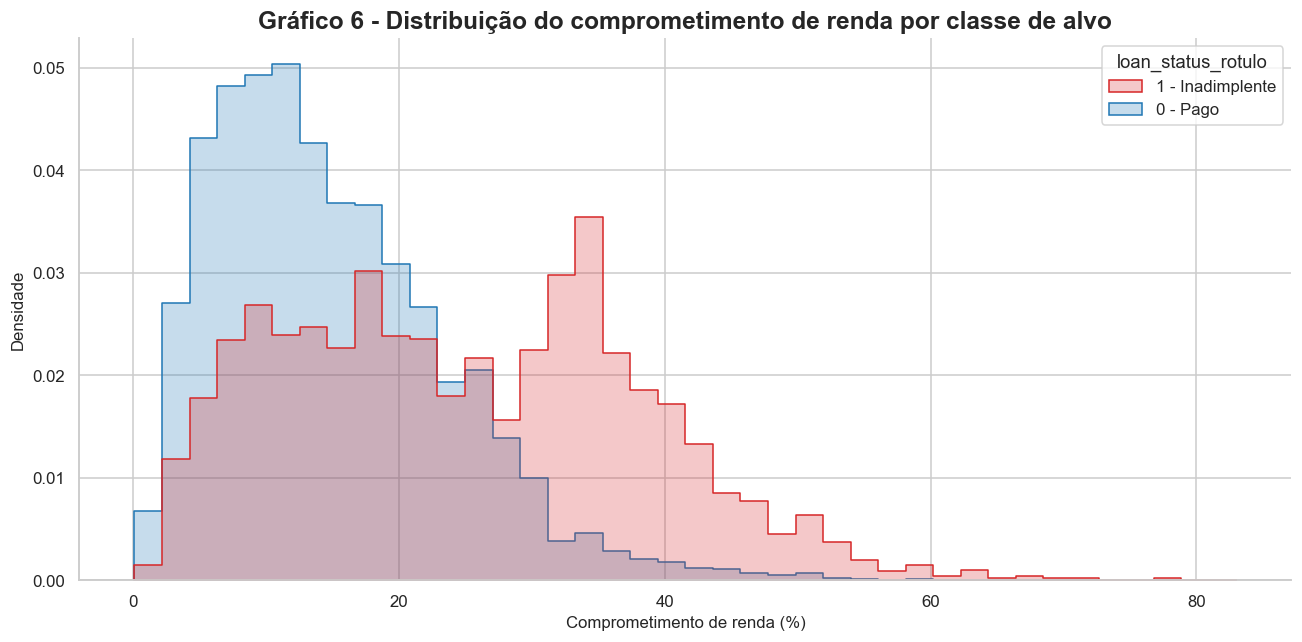

In [22]:
# Coluna calculada: comprometimento_renda = (loan_amnt / person_income) * 100
# Razão entre o montante solicitado e a renda anual.
COLUNA_CALCULADA = 'comprometimento_renda'

print(BAR)
print(f'COLUNA CALCULADA: {COLUNA_CALCULADA}')
print(BAR)

df[COLUNA_CALCULADA] = (df['loan_amnt'] / df['person_income']) * 100

print()
print('--- ESTATÍSTICAS DA COLUNA CALCULADA ---')
print(f'{COLUNA_CALCULADA} = (loan_amnt / person_income) * 100')
display(df[[COLUNA_CALCULADA]].describe().T.round(2))
print('Correlação com o alvo ............................: {}'.format(round(df[COLUNA_CALCULADA].corr(df[TARGET]), 4)))
print('Correlação com loan_percent_income ...............: {}'.format(round(df[COLUNA_CALCULADA].corr(df['loan_percent_income']), 4)))
print(BAR)

fig, ax = plt.subplots(figsize=(12, 6))
sns.histplot(
    data=df,
    x=COLUNA_CALCULADA,
    hue=COLUNA_ALVO_ROTULO,
    palette=PALETA_ALVO,
    bins=40,
    element='step',
    stat='density',
    common_norm=False,
    ax=ax,
)
ax.set_title('Gráfico 6 - Distribuição do comprometimento de renda por classe de alvo',
             fontsize=16, fontweight='bold')
ax.set_xlabel('Comprometimento de renda (%)')
ax.set_ylabel('Densidade')
plt.tight_layout()
plt.show()

# FASE 4 - ENCODING, BALANCEAMENTO E ESCALONAMENTO SEGURO

A separação treino/teste já foi executada no fim da Fase 2, antes da imputação, e é
reaproveitada aqui sem qualquer novo sorteio. `stratify=y` preservou a proporção de
inadimplentes nas duas bases, e nenhum parâmetro aprendido foi estimado com as linhas
de teste.

## Escolha de One-Hot Encoding e não Label Encoding

As quatro variáveis categóricas recebem a mesma técnica por decisão de padronização do
pipeline, mas cada uma tem uma razão própria:

- **`person_home_ownership` e `loan_intent`** são estritamente nominais. `RENT`, `OWN`,
  `MORTGAGE` e `OTHER` não ocupam posições numa escala, e `MEDICAL` não é maior nem
  menor que `EDUCATION`. O Label Encoder transformaria rótulos em números e criaria
  uma ordem que não existe no dado.
- **`cb_person_default_on_file`** é binária. Com `drop='first'`, o One-Hot gera uma
  coluna só, numericamente idêntica a um Label Encoding, mas sem manter no código duas
  técnicas diferentes para o mesmo problema.
- **`loan_grade`** é ordinal, de A a G. Ainda assim o One-Hot foi mantido porque as
  faixas não são equidistantes: a distância entre C e D não tem o mesmo significado
  de negócio que a distância entre A e B, e um Label Encoder as trataria como iguais.
  São apenas 7 níveis, então o custo em colunas é irrelevante.

O `drop='first'` remove uma categoria de referência de cada variável. Sem ele, as
colunas geradas seriam redundentes entre si (a dummy trap): o KNN receberia a mesma
informação duas vezes, exatamente como aconteceu com a coluna calculada, e a Árvore
teria cortes duplicados.

O `handle_unknown='ignore'` é uma precaução, não um detalhe: as categorias foram
aprendidas apenas no treino, e um nível que apareça só no teste não pode gerar uma
coluna nova nem interromper a execução.

In [23]:
# =============================================================================
# ENCODING DAS VARIÁVEIS CATEGÓRICAS
# =============================================================================
# X e y são recortados com a separação definida na Fase 2, sem novo sorteio.

# Variáveis que serão usadas como entradas para os modelos de predição:
COLUNAS_PREDITORAS = [c for c in COLUNAS_BASE if c != TARGET] + [
    'loan_int_rate_ausente',
    COLUNA_CALCULADA,
]
DESCARTADAS = [c for c in df.columns if c not in COLUNAS_PREDITORAS and c != TARGET]

X = df[COLUNAS_PREDITORAS].copy()
y = df[TARGET].copy()

X_treino = X.loc[INDICES_TREINO].copy()
X_teste = X.loc[INDICES_TESTE].copy()
y_treino = y.loc[INDICES_TREINO].copy()
y_teste = y.loc[INDICES_TESTE].copy()

print(BAR)
print('CONJUNTOS DE DADOS PARA MODELAÇÃO')
print(BAR)
print('Coluna(s) descartada(s) como preditora(s) ..............: {}'.format(', '.join(DESCARTADAS)))
print(LIN)
print('Amostras de treino ..............................: {}'.format(padrao_br(len(X_treino))))
print('Amostras de teste ...............................: {}'.format(padrao_br(len(X_teste))))
print('Divisão nominal ..................................: 80,00% / 20,00%')
print('Inadimplentes no treino ........................: {} ({:.2f}%)'.format(
    padrao_br(int(y_treino.sum())), y_treino.mean() * 100))
print('Inadimplentes no teste .........................: {} ({:.2f}%)'.format(
    padrao_br(int(y_teste.sum())), y_teste.mean() * 100))
print(BAR)

# Transformar as vriáveis categóricas em representações numéricas:
CATEGORICAS = X_treino.select_dtypes(exclude=[np.number]).columns.tolist()
NIVEIS_OBSERVADOS = {coluna: sorted(X_treino[coluna].unique().tolist()) for coluna in CATEGORICAS}

CODIFICADOR = OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False, dtype=np.int8)
CODIGOS_TREINO = CODIFICADOR.fit_transform(X_treino[CATEGORICAS])
CODIGOS_TESTE = CODIFICADOR.transform(X_teste[CATEGORICAS])
NOMES_DOS_CODIGOS = CODIFICADOR.get_feature_names_out(CATEGORICAS)

# Substituir as colunas categóricas pelo formato numérico na amostra de treino
X_treino = pd.concat([
    X_treino.drop(columns=CATEGORICAS),
    pd.DataFrame(CODIGOS_TREINO, columns=NOMES_DOS_CODIGOS, index=X_treino.index),
], axis=1)

# Substituir as colunas categóricas pelo formato numérico na amostra de teste
X_teste = pd.concat([
    X_teste.drop(columns=CATEGORICAS),
    pd.DataFrame(CODIGOS_TESTE, columns=NOMES_DOS_CODIGOS, index=X_teste.index),
], axis=1)

# Apresentar as transformações do One-Hot Encoding
tabela_encoding = pd.DataFrame([
    {
        'Categórica': coluna,
        'Descrição': DICIONARIO_COLUNAS[coluna],
        'Categorias observadas': ', '.join(NIVEIS_OBSERVADOS[coluna]),
        'Níveis': len(NIVEIS_OBSERVADOS[coluna]),
        'Colunas geradas': len(NIVEIS_OBSERVADOS[coluna]) - 1,
    }
    for coluna in CATEGORICAS
])
display(tabela_encoding)

print('Categorias do encoding: {} (aprendidas no treino)'.format(padrao_br(len(NOMES_DOS_CODIGOS))))
print('Total de colunas preditoras depois do encoding: {}'.format(padrao_br(len(X_treino.columns))))

CONJUNTOS DE DADOS PARA MODELAÇÃO
Coluna(s) descartada(s) como preditora(s) ..............: loan_status_rotulo
--------------------------------------------------------------
Amostras de treino ..............................: 25.932
Amostras de teste ...............................: 6.484
Divisão nominal ..................................: 80,00% / 20,00%
Inadimplentes no treino ........................: 5.671 (21.87%)
Inadimplentes no teste .........................: 1.418 (21.87%)


,Categórica,Descrição,Categorias observadas,Níveis,Colunas geradas
0,person_home_ownership,Situação do imóvel do cliente,"MORTGAGE, OTHER, OWN, RENT",4,3
1,loan_intent,Finalidade do empréstimo,"DEBTCONSOLIDATION, EDUCATION, HOMEIMPROVEMENT,...",6,5
2,loan_grade,Faixa de risco do empréstimo (A-G),"A, B, C, D, E, F, G",7,6
3,cb_person_default_on_file,Default registrado no histórico de crédito,"N, Y",2,1


Categorias do encoding: 15 (aprendidas no treino)
Total de colunas preditoras depois do encoding: 24


## Por que Random Under Sampling

O desbalanceamento é de 3,58 para 1, e a consequência prática já apareceu na Fase 1:
um classificador ingênuo acerta 78% dos casos apenas respondendo "paga" sempre, sem
usar informação nenhuma. O balanceamento existe para tirar esse atalho.

A técnica escolhida é o **Random Under Sampling**, que descarta registros da classe
majoritária até igualar as duas:

- **Preserva a classe minoritária por inteiro**, que é justamente a informação escassa
  e a que o banco perde dinheiro ao errar. O SMOTE, alternative mais citado, fabricaria
  amostras sintéticas interpolando vizinhos minoritários: num problema com 24 features
  e apenas 5.671 pontos da classe minoritária, o espaço é raso demais para que a
  interpolação produza clientes plausíveis.
- **O KNN sofre mais com o SMOTE do que com o RUS.** O KNN não tem parâmetro para
  aprender: ele classifica pela vizinhança. Amostras sintéticas passariam a contar como
  vizinhos reais e a deslocar a fronteira de decisão para um lugar que não existe na
  carteira de clientes.
- **O custo é declarado:** o RUS descarta cerca de 72% da classe majoritária e faz a
  base de treino passar de 25.932 para 11.342 linhas. É a mesma perda de informação que
  o SMOTE evitaria, concentrada em uma classe que é 78% da base.

Regra de ouro do balanceamento: ele é aplicado **somente no treino**. O teste preserva
a distribuição real de 78,13% / 21,87%, porque é contra essa proporção que o modelo
será julgado em produção. Reamostrar o teste inflaria as métricas e esconderia exatamente
o problema que a operação precisa enxergar.

BALANCEAMENTO POR RANDOM UNDER SAMPLING
Semente utilizada ...............................: 42
Amostras de treino antes do balanceamento .......: 25.932
Amostras de treino depois do balanceamento ......: 11.342
Amostras de teste  ..............................: 6.484
--------------------------------------------------------------
0 - Pago                   20.261 -> 5.671
1 - Inadimplente           5.671 -> 5.671
--------------------------------------------------------------
Registros da classe majoritária descartados ......: 14.590
Distribuição do alvo no teste antes ..............: 21.87% de inadimplentes
Distribuição do alvo no teste depois .............: 21.87% de inadimplentes
Base de teste idêntica antes e depois ...........: True


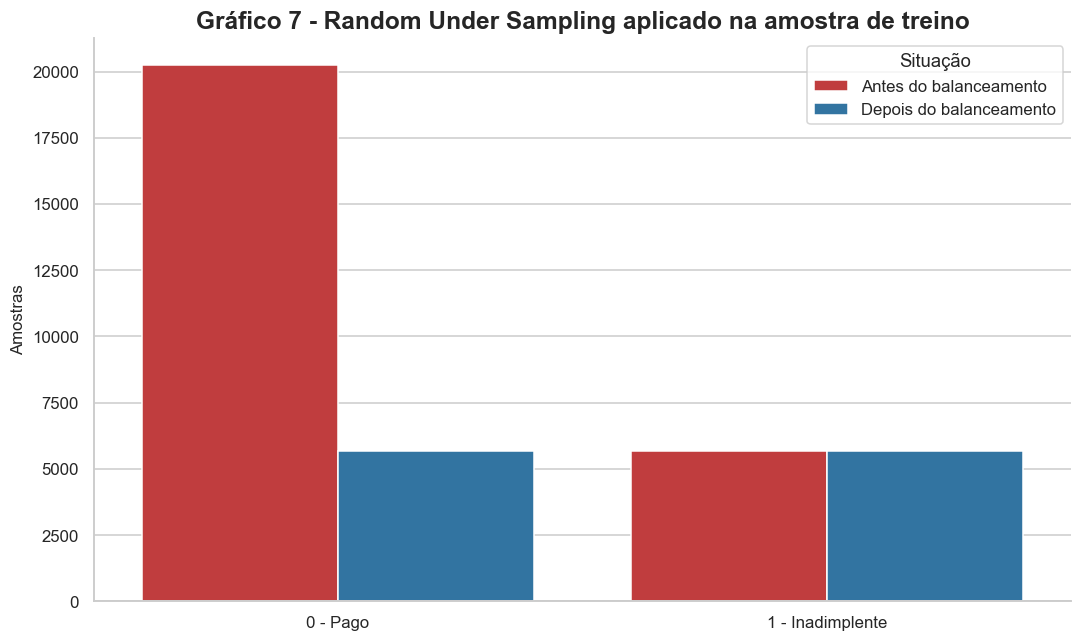

In [24]:
# =============================================================================
# BALANCEAMENTO DE CLASSES
# =============================================================================
# Técnica aplicada: Random Under Sampling. 
# A classe minoritária é preservada integralmente e a majoritária
# é subamostrada sem reposição até a mesma quantidade.
X_TESTE_ANTES = X_teste.copy()
Y_TESTE_ANTES = y_teste.copy()

contagem_treino = y_treino.value_counts().sort_index()
CLASSE_MINORIA = int(contagem_treino.idxmin())
CLASSE_MAIORIA = int(contagem_treino.idxmax())

# Subamostragem da classe majoritária (undersampling)
sorteio = np.random.default_rng(SEMENTE)
indices_minoria = y_treino.index[y_treino == CLASSE_MINORIA].to_numpy()
indices_maioria = y_treino.index[y_treino == CLASSE_MAIORIA].to_numpy()
indices_balanceados = np.concatenate([
    indices_minoria,
    sorteio.choice(indices_maioria, size=len(indices_minoria), replace=False),
])

X_treino_bal = X_treino.loc[indices_balanceados].reset_index(drop=True)
y_treino_bal = y_treino.loc[indices_balanceados].reset_index(drop=True)
contagem_balanceada = y_treino_bal.value_counts().sort_index()

print(BAR)
print('BALANCEAMENTO POR RANDOM UNDER SAMPLING')
print(BAR)
print('Semente utilizada ...............................: {}'.format(padrao_br(SEMENTE)))
print('Amostras de treino antes do balanceamento .......: {}'.format(padrao_br(len(X_treino))))
print('Amostras de treino depois do balanceamento ......: {}'.format(padrao_br(len(X_treino_bal))))
print('Amostras de teste  ..............................: {}'.format(padrao_br(len(X_teste))))
print(LIN)
print('{:<26} {} -> {}'.format(
    ROTULO_TARGET[CLASSE_MAIORIA],
    padrao_br(contagem_treino[CLASSE_MAIORIA]),
    padrao_br(contagem_balanceada[CLASSE_MAIORIA])))
print('{:<26} {} -> {}'.format(
    ROTULO_TARGET[CLASSE_MINORIA],
    padrao_br(contagem_treino[CLASSE_MINORIA]),
    padrao_br(contagem_balanceada[CLASSE_MINORIA])))
print(LIN)
print('Registros da classe majoritária descartados ......: {}'.format(
    padrao_br(contagem_treino[CLASSE_MAIORIA] - contagem_balanceada[CLASSE_MAIORIA])))

# Prova de que a base de teste atravessou o balanceamento sem ser tocada.
teste_intacto = X_TESTE_ANTES.equals(X_teste) and Y_TESTE_ANTES.equals(y_teste)
print('Distribuição do alvo no teste antes ..............: {:.2f}% de inadimplentes'.format(
    Y_TESTE_ANTES.mean() * 100))
print('Distribuição do alvo no teste depois .............: {:.2f}% de inadimplentes'.format(
    y_teste.mean() * 100))
print('Base de teste idêntica antes e depois ...........: {}'.format(teste_intacto))
print(BAR)

fig, ax = plt.subplots(figsize=(10, 6))
comparacao_balanceamento = pd.DataFrame({
    'Classe': [ROTULO_TARGET[CLASSE_MAIORIA], ROTULO_TARGET[CLASSE_MINORIA]],
    'Antes do balanceamento': [contagem_treino[CLASSE_MAIORIA], contagem_treino[CLASSE_MINORIA]],
    'Depois do balanceamento': [contagem_balanceada[CLASSE_MAIORIA], contagem_balanceada[CLASSE_MINORIA]],
}).melt(id_vars='Classe', var_name='Situação', value_name='Amostras')
sns.barplot(
    data=comparacao_balanceamento,
    x='Classe',
    y='Amostras',
    hue='Situação',
    palette={'Antes do balanceamento': COR_COM_DEFAULT, 'Depois do balanceamento': COR_SEM_DEFAULT},
    ax=ax,
)
ax.set_title('Gráfico 7 - Random Under Sampling aplicado na amostra de treino',
             fontsize=16, fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('Amostras')
plt.tight_layout()
plt.show()

## Por que só o KNN recebe escalonamento

O `StandardScaler` é aplicado apenas às 8 variáveis contínuas, e apenas nas duas etapas
corretas: `fit_transform` no treino balanceado e `transform` no teste.

Os indicadores binários e as colunas do One-Hot ficam de fora de propósito. Eles já
valem 0 ou 1 e a padronização os transformaria em números negativos e positivos sem
significado, além de esticar a distância de uma dummy em relação ao resto do vetor —
justamente o oposto do que se quer em um KNN.

A Árvore de Decisão dispensa a etapa, e a célula seguinte prova isso em vez de apenas
afirmar: duas árvores com o mesmo hiperparâmetro, uma treinada com as variáveis
escaladas e outra sem, tomam decisões idênticas. Isso acontece porque a árvore separa
os dados por cortes monotônicos em um único atributo, e um corte não muda de lugar ao
multiplicar a coluna por uma constante. Ela é indiferente à escala, mas não ao
descompasso entre treino e teste, e a contraprova do código mostra por quê.

In [25]:
# =============================================================================
# ESCALONAMENTO DAS VARIÁVEIS CONTÍNUAS E DISPENSA PARA A ÁRVORE
# =============================================================================

# Só as variáveis contínuas são escalonadas. Os indicadores binários e as colunas
# do encoding one-hot já valem 0 ou 1 e seriam distorcidos pela padronização.
COLUNAS_ESCALONAVEIS = [
    'person_age',
    'person_income',
    'person_emp_length',
    'loan_amnt',
    'loan_int_rate',
    'loan_percent_income',
    'cb_person_cred_hist_length',
    COLUNA_CALCULADA,
]

# Cópias preservadas são feitas ANTES da padronização, para servir de contraprova.
X_TREINO_SEM_ESCALA = X_treino_bal.copy()
X_TESTE_SEM_ESCALA = X_teste.copy()

# O scaler é ajustado apenas no treino balanceado:
ESCALADOR = StandardScaler()
X_treino_bal[COLUNAS_ESCALONAVEIS] = ESCALADOR.fit_transform(X_treino_bal[COLUNAS_ESCALONAVEIS])
X_teste[COLUNAS_ESCALONAVEIS] = ESCALADOR.transform(X_teste[COLUNAS_ESCALONAVEIS])

# Escala original de cada variável, que é exatamente o que a padronização corrige.
comparacao_escalonamento = pd.DataFrame({
    'Variável': COLUNAS_ESCALONAVEIS,
    'Média': [X_TREINO_SEM_ESCALA[c].mean() for c in COLUNAS_ESCALONAVEIS],
    'Desvio padrão': [X_TREINO_SEM_ESCALA[c].std() for c in COLUNAS_ESCALONAVEIS],
})
comparacao_escalonamento['Coef. variação'] = (
    comparacao_escalonamento['Desvio padrão'] / comparacao_escalonamento['Média']
)

print(BAR)
print('ESCALONAMENTO SEGURO (STANDARD SCALER)')
print(BAR)
print('Variáveis contínuas escalonadas ..................: {}'.format(padrao_br(len(COLUNAS_ESCALONAVEIS))))
print('Indicadores e colunas de encoding preservados ...: {}'.format(
    padrao_br(len(X_treino_bal.columns) - len(COLUNAS_ESCALONAVEIS))))
print(LIN)
display(comparacao_escalonamento.round(4))
print(BAR)
print('Média e desvio padrão do scaler são os do treino balanceado: a base de teste')
print('foi apenas transformada com eles, sem jamais contribuir para o ajuste.')
print(BAR)

# A árvore dispensa escalonamento: duas árvores com o mesmo hiperparâmetro, uma
# treinada com as variáveis padronizadas e outra sem, decidem exatamente igual,
# porque a árvore separa por cortes e o corte não depende da unidade de medida.
# A contraprova mostra que a escala precisa ser a mesma entre treino e teste.
ARVORE_COM_ESCALA = DecisionTreeClassifier(max_depth=5, random_state=SEMENTE)
ARVORE_SEM_ESCALA = DecisionTreeClassifier(max_depth=5, random_state=SEMENTE)
ARVORE_COM_ESCALA.fit(X_treino_bal, y_treino_bal)
ARVORE_SEM_ESCALA.fit(X_TREINO_SEM_ESCALA, y_treino_bal)
PREVISOES_COM = ARVORE_COM_ESCALA.predict(X_teste)
PREVISOES_SEM = ARVORE_SEM_ESCALA.predict(X_TESTE_SEM_ESCALA)
PREVISOES_ESCALA_INCOMPATIVEL = ARVORE_SEM_ESCALA.predict(X_teste)

print(BAR)
print('ANÁLISE SOBRE A NECESSIDADE DE ESCALONAMENTO NA ÁRVORE DE DECISÃO')
print(BAR)
print('Árvore com escalonamento .....................: {}%'.format(
    padrao_br(accuracy_score(y_teste, PREVISOES_COM) * 100, 2)))
print('Árvore sem escalonamento .....................: {}%'.format(
    padrao_br(accuracy_score(y_teste, PREVISOES_SEM) * 100, 2)))
print('Previsões divergentes entre as duas ..........: {} de {}'.format(
    padrao_br(int((PREVISOES_COM != PREVISOES_SEM).sum())), padrao_br(len(y_teste))))
print(LIN)
print('Contraprova: a árvore treinada sem escala e prevista sobre o teste já')
print('escalado acerta {}%, porque passa a comparar cortes que valem em unidades'.format(
    padrao_br(accuracy_score(y_teste, PREVISOES_ESCALA_INCOMPATIVEL) * 100, 2)))
print('diferentes. A árvore não precisa de padronização, mas precisa que treino e')
print('teste estejam na mesma escala — e é o mesmo acoplamento que exige o scaler no KNN.')
print(BAR)

ESCALONAMENTO SEGURO (STANDARD SCALER)
Variáveis contínuas escalonadas ..................: 8
Indicadores e colunas de encoding preservados ...: 16
--------------------------------------------------------------


,Variável,Média,Desvio padrão,Coef. variação
0,person_age,27.6650,6.3233,0.2286
1,person_income,59828.0781,49507.5939,0.8275
2,person_emp_length,4.5103,3.9191,0.8689
3,loan_amnt,9983.7374,6528.7009,0.6539
4,loan_int_rate,11.7110,3.2330,0.2761
5,loan_percent_income,0.1978,0.1220,0.6167
6,cb_person_cred_hist_length,5.7895,4.0991,0.7080
7,comprometimento_renda,19.8758,12.2416,0.6159


Média e desvio padrão do scaler são os do treino balanceado: a base de teste
foi apenas transformada com eles, sem jamais contribuir para o ajuste.
ANÁLISE SOBRE A NECESSIDADE DE ESCALONAMENTO NA ÁRVORE DE DECISÃO
Árvore com escalonamento .....................: 87,99%
Árvore sem escalonamento .....................: 87,99%
Previsões divergentes entre as duas ..........: 0 de 6.484
--------------------------------------------------------------
Contraprova: a árvore treinada sem escala e prevista sobre o teste já
escalado acerta 28,49%, porque passa a comparar cortes que valem em unidades
diferentes. A árvore não precisa de padronização, mas precisa que treino e
teste estejam na mesma escala — e é o mesmo acoplamento que exige o scaler no KNN.


# FASE 5 - Modelagem e Validação (O Desafio do Overfitting)

Cada configuração é medida em três bases ao mesmo tempo, e cada uma tem um papel
diferente na decisão:

- **Validação cruzada dentro do treino**, em 5 dobras estratificadas com a mesma semente
  do projeto. É o único critério que escolhe o hiperparâmetro.
- **Treino inteiro**, que revela quanto o modelo decorou os dados que já viu.
- **Teste**, que fica fora da escolha. Se ele participasse da seleção, as métricas da
  Fase 6 deixariam de medir generalização: estariam apenas otimizadas.

As duas grades vão além do mínimo de quatro valores, e não por excesso de zelo. Com
K = 3, 5, 7 e 9, o F1 de teste crescia a cada passo e a curva simplesmente terminava no
fim da busca, sem nunca mostrar onde o ganho acaba. Sem estender a grade, "K = 9 é o
melhor" seria apenas "K = 9 é o último que eu testei".

OTIMIZAÇÃO DE HIPERPARÂMETROS
Validação cruzada: 5 dobras estratificadas, semente 42
--------------------------------------------------------------
--- KNN: variação de n_neighbors ---


,Configuração,Acurácia treino,Precisão treino,Recall treino,F1 treino,Acurácia teste,Precisão teste,Recall teste,F1 teste,F1 validação,Desvio F1 validação,Gap Acurácia,Gap F1
0,3,88.87,90.29,87.11,88.67,79.46,52.04,77.50,62.27,78.43,0.60,9.41,26.40
1,5,86.33,87.98,84.17,86.03,81.18,54.88,78.56,64.62,79.32,0.59,5.15,21.41
2,7,84.67,86.87,81.68,84.20,81.85,56.17,77.36,65.08,79.50,0.75,2.82,19.12
3,9,84.09,86.47,80.81,83.55,82.25,56.94,77.22,65.55,79.51,0.44,1.84,18.00
4,11,83.34,85.76,79.95,82.75,82.60,57.60,77.50,66.09,79.60,0.57,0.74,16.66
5,15,82.47,85.27,78.50,81.75,82.96,58.41,76.66,66.30,79.41,0.84,-0.49,15.45
6,21,81.72,84.62,77.53,80.92,83.24,58.99,76.59,66.65,79.45,0.70,-1.52,14.27


--- ÁRVORE DE DECISÃO: variação de max_depth ---


,Configuração,Acurácia treino,Precisão treino,Recall treino,F1 treino,Acurácia teste,Precisão teste,Recall teste,F1 teste,F1 validação,Desvio F1 validação,Gap Acurácia,Gap F1
0,3,80.48,90.64,67.98,77.69,88.29,75.40,68.97,72.04,77.75,0.88,-7.81,5.65
1,5,82.85,89.86,74.06,81.20,87.99,71.75,74.33,73.02,80.78,0.83,-5.14,8.18
2,7,84.99,93.80,74.94,83.32,89.62,77.45,74.12,75.75,81.73,1.03,-4.63,7.57
3,10,87.48,96.72,77.59,86.11,90.10,78.61,75.18,76.86,82.23,0.78,-2.62,9.25
4,Ilimitada,100.00,100.00,100.00,100.00,81.12,54.54,82.23,65.58,81.06,0.35,18.88,34.42


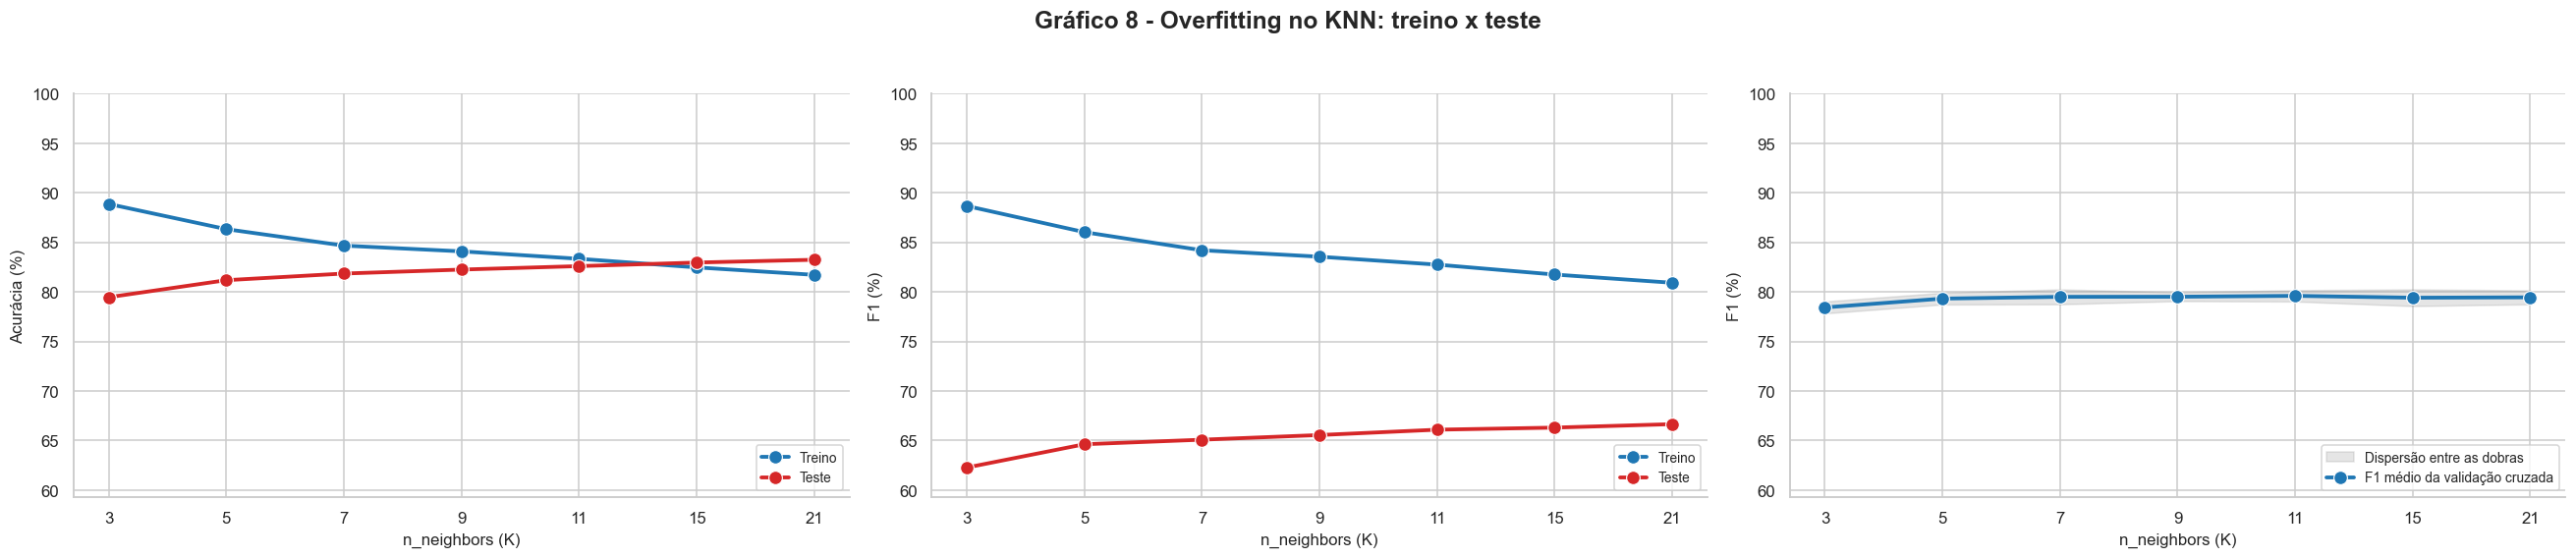

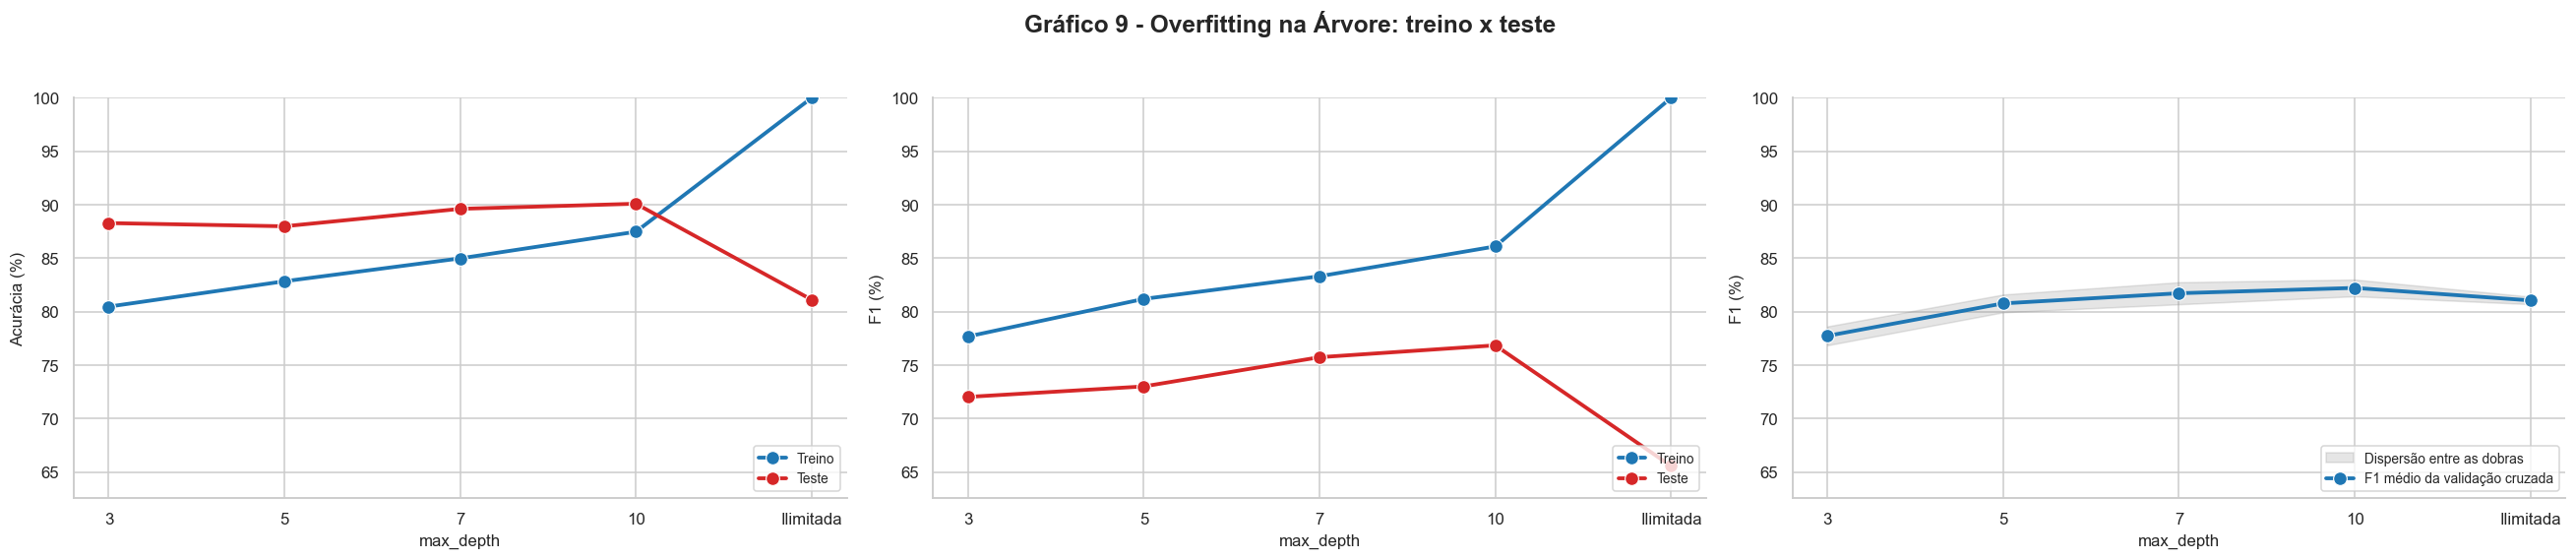

CONFIGURAÇÕES SELECIONADAS PARA CADA MODELO
Critério ..................................: maior F1 médio da validação cruzada
KNN .......................: n_neighbors = 11
Árvore de Decisão .........: max_depth = 10


In [26]:
# =============================================================================
# MODELAGEM E VARIAÇÃO DOS HIPERPARÂMETROS DE COMPLEXIDADE
# =============================================================================
# Todos os cenários recebem exatamente a mesma base de treino balanceada e escalada.
# Para cada configuração, o modelo é avaliado na validação cruzada, no treino e no
# teste: a divergência entre treino e teste é um sinal de overfitting, e a validação
# cruzada é o único critério que decide qual configuração é adotada.
VALIDADORES = StratifiedKFold(n_splits=DOBRAS_VALIDACAO, shuffle=True, random_state=SEMENTE)
VALORES_K = [3, 5, 7, 9, 11, 15, 21]
VALORES_PROFUNDIDADE = [3, 5, 7, 10, None]
NOMES_DAS_CLASSES = [ROTULO_TARGET[classe] for classe in sorted(ROTULO_TARGET)]

def avaliar_configuracoes(nome_modelo, rotulo_parametro, configuracoes):
    ''' Treina e avalia configurações diferentes de um modelo, fazendo
        comparações do seu desempenho por métricas como Acurácia, 
        Precisão, Recall e F1 Score.'''
    linhas = []
    for ordem, (rotulo, modelo) in enumerate(configuracoes, start=1):
        # Validação cruzada dentro do treino: é este número que escolhe a configuração.
        # O teste não entra em nenhum cálculo desta função.
        notas = cross_val_score(modelo, X_treino_bal, y_treino_bal, cv=VALIDADORES, scoring='f1')

        modelo.fit(X_treino_bal, y_treino_bal)
        avaliacoes = (
            ('Treino', y_treino_bal, modelo.predict(X_treino_bal)),
            ('Teste', y_teste, modelo.predict(X_teste)),
        )
        for nome_base, alvo, previsoes in avaliacoes:
            linhas.append({
                'Modelo': nome_modelo,
                'Hiperparâmetro': rotulo_parametro,
                'Configuração': rotulo,
                'Ordem': ordem,
                'Base': nome_base,
                'F1 validação': round(notas.mean() * 100, 2),
                'Desvio F1 validação': round(notas.std() * 100, 2),
                'Acurácia': round(accuracy_score(alvo, previsoes) * 100, 2),
                'Precisão': round(precision_score(alvo, previsoes, zero_division=0) * 100, 2),
                'Recall': round(recall_score(alvo, previsoes, zero_division=0) * 100, 2),
                'F1': round(f1_score(alvo, previsoes, zero_division=0) * 100, 2),
            })
    return pd.DataFrame(linhas)


def grafico_overfitting(tabela, titulo, rotulo_parametro):
    fig, eixos = plt.subplots(1, 3, figsize=(24, 5))
    piso = float(tabela[['Acurácia', 'F1']].min().min()) - 3
    for eixo, metrica in zip(eixos, ['Acurácia', 'F1']):
        sns.lineplot(
            data=tabela,
            x='Ordem',
            y=metrica,
            hue='Base',
            hue_order=['Treino', 'Teste'],
            markers=True,
            dashes=False,
            palette={'Treino': COR_SEM_DEFAULT, 'Teste': COR_COM_DEFAULT},
            marker='o',
            markersize=9,
            linewidth=2.5,
            ax=eixo,
        )
        marcas = tabela.drop_duplicates(subset=['Ordem']).sort_values('Ordem')['Configuração'].tolist()
        eixo.set_xticks(sorted(tabela['Ordem'].unique()))
        eixo.set_xticklabels(marcas)
        eixo.set_ylim(piso, 100)
        eixo.set_xlabel(rotulo_parametro)
        eixo.set_ylabel('{} (%)'.format(metrica))
        eixo.legend(loc='lower right', fontsize=9)

    # Terceiro painel: o F1 da validação cruzada, com a dispersão entre as dobras.
    dobras = tabela.drop_duplicates(subset=['Ordem']).sort_values('Ordem')
    eixo = eixos[2]
    eixo.fill_between(
        dobras['Ordem'],
        dobras['F1 validação'] - dobras['Desvio F1 validação'],
        dobras['F1 validação'] + dobras['Desvio F1 validação'],
        color=COR_NEUTRA,
        alpha=0.20,
        label='Dispersão entre as dobras',
    )
    sns.lineplot(
        data=dobras,
        x='Ordem',
        y='F1 validação',
        marker='o',
        markersize=9,
        linewidth=2.5,
        color=COR_SEM_DEFAULT,
        label='F1 médio da validação cruzada',
        ax=eixo,
    )
    eixo.set_xticks(sorted(dobras['Ordem'].unique()))
    eixo.set_xticklabels(dobras['Configuração'].tolist())
    eixo.set_ylim(piso, 100)
    eixo.set_xlabel(rotulo_parametro)
    eixo.set_ylabel('F1 (%)')
    eixo.legend(loc='lower right', fontsize=9)

    fig.suptitle(titulo, fontsize=16, fontweight='bold', y=1.03)
    plt.tight_layout()
    plt.show()


CONFIGURACOES_KNN = [
    (str(k), KNeighborsClassifier(n_neighbors=k)) for k in VALORES_K
]
TABELA_KNN = avaliar_configuracoes('KNN', 'n_neighbors (K)', CONFIGURACOES_KNN)

CONFIGURACOES_ARVORE = []
for profundidade in VALORES_PROFUNDIDADE:
    rotulo = 'Ilimitada' if profundidade is None else str(profundidade)
    CONFIGURACOES_ARVORE.append(
        (rotulo, DecisionTreeClassifier(max_depth=profundidade, random_state=SEMENTE))
    )
TABELA_ARVORE = avaliar_configuracoes('Árvore de Decisão', 'max_depth', CONFIGURACOES_ARVORE)

METRICAS = ['Acurácia', 'Precisão', 'Recall', 'F1']

def montar_comparativo(tabela):
    '''Junta, para cada configuração, as métricas de treino, de teste e de validação.'''
    treino = tabela[tabela['Base'] == 'Treino'].set_index('Configuração')
    teste = tabela[tabela['Base'] == 'Teste'].set_index('Configuração')
    comparativo = treino[METRICAS].add_suffix(' treino').join(teste[METRICAS].add_suffix(' teste'))
    comparativo['F1 validação'] = treino['F1 validação']
    comparativo['Desvio F1 validação'] = treino['Desvio F1 validação']
    comparativo['Gap Acurácia'] = (
        comparativo['Acurácia treino'] - comparativo['Acurácia teste']
    ).round(2)
    comparativo['Gap F1'] = (
        comparativo['F1 treino'] - comparativo['F1 teste']
    ).round(2)
    return comparativo

COMPARATIVO_KNN = montar_comparativo(TABELA_KNN)
COMPARATIVO_ARVORE = montar_comparativo(TABELA_ARVORE)

TABELA_KNN_TREINO = TABELA_KNN[TABELA_KNN['Base'] == 'Treino'].set_index('Configuração')
TABELA_ARVORE_TREINO = TABELA_ARVORE[TABELA_ARVORE['Base'] == 'Treino'].set_index('Configuração')

print(BAR)
print('OTIMIZAÇÃO DE HIPERPARÂMETROS')
print(BAR)
print(f'Validação cruzada: {DOBRAS_VALIDACAO} dobras estratificadas, semente {SEMENTE}')
print(LIN)
print('--- KNN: variação de n_neighbors ---')
display(COMPARATIVO_KNN.reset_index().rename(columns={'index': 'K'}))
print('--- ÁRVORE DE DECISÃO: variação de max_depth ---')
display(COMPARATIVO_ARVORE.reset_index().rename(columns={'index': 'Profundidade'}))
print(BAR)

grafico_overfitting(TABELA_KNN, 'Gráfico 8 - Overfitting no KNN: treino x teste', 'n_neighbors (K)')
grafico_overfitting(TABELA_ARVORE, 'Gráfico 9 - Overfitting na Árvore: treino x teste', 'max_depth')

# Seleção da configuração de cada modelo pelo maior F1 médio da validação cruzada. O
# F1 harmoniza precisão e recall da classe dos inadimplentes em uma única nota, e como
# a validação roda apenas dentro do treino, o teste permanece intacto e continua
# disponível como medida independente de generalização.
MELHOR_KNN_CONFIG = TABELA_KNN_TREINO['F1 validação'].idxmax()
MELHOR_ARVORE_CONFIG = TABELA_ARVORE_TREINO['F1 validação'].idxmax()

# Os modelos avaliados nas próximas etapas serão treinados com essas mesmas configurações.
MELHOR_KNN = KNeighborsClassifier(n_neighbors=int(MELHOR_KNN_CONFIG)).fit(X_treino_bal, y_treino_bal)
MELHOR_ARVORE = DecisionTreeClassifier(
    max_depth=None if MELHOR_ARVORE_CONFIG == 'Ilimitada' else int(MELHOR_ARVORE_CONFIG),
    random_state=SEMENTE,
).fit(X_treino_bal, y_treino_bal)

print(BAR)
print('CONFIGURAÇÕES SELECIONADAS PARA CADA MODELO')
print(BAR)
print('Critério ..................................: maior F1 médio da validação cruzada')
print('KNN .......................: n_neighbors = {}'.format(MELHOR_KNN_CONFIG))
print('Árvore de Decisão .........: max_depth = {}'.format(MELHOR_ARVORE_CONFIG))
print(BAR)

## Como o overfitting foi diagnosticado

Cada configuração foi medida em três lugares ao mesmo tempo:

- **Validação cruzada** no treino, em 5 dobras estratificadas. É o critério de escolha.
- **Treino inteiro**, que mostra o quanto o modelo decorou o que já viu.
- **Teste**, que não participa da escolha e serve de medida final de generalização.

O **Gap** é um indicador de possível overfitting: é a métrica de treino menos a de
teste. Quanto maior o gap, maior a probabilidade de o modelo ter apenas decorado os
dados de treino. Para a Árvore, a acurácia não serve a esse fim e o motivo está
explicado no fim desta nota.

### Critério de escolha

A configuração adotada em cada modelo é a que apresenta o maior **F1 médio da
validação cruzada** da classe dos inadimplentes. O F1 reúne precisão e recall em uma
única nota, e a validação cruzada roda inteiramente dentro do treino, de modo que o
teste permanece uma base independente e continua disponível para medir generalização.

O gap de F1 aparece aqui como diagnóstico de overfitting, e não como critério de
escolha.

### Modelo KNN

| K | F1 validação | Desvio | Acurácia treino | Acurácia teste | F1 teste | Gap de F1 |
|---|---|---|---|---|---|---|
| 3 | 78,43% | 0,60 | 88,87% | 79,46% | 62,27% | 26,40 |
| 5 | 79,32% | 0,59 | 86,33% | 81,18% | 64,62% | 21,41 |
| 7 | 79,50% | 0,75 | 84,67% | 81,85% | 65,08% | 19,12 |
| 9 | 79,51% | 0,44 | 84,09% | 82,25% | 65,55% | 18,00 |
| **11** | **79,60%** | 0,57 | 83,34% | 82,60% | 66,09% | 16,66 |
| 15 | 79,41% | 0,84 | 82,47% | 82,96% | 66,30% | 15,45 |
| 21 | 79,45% | 0,70 | 81,72% | 83,24% | 66,65% | 14,27 |

O F1 de validação cruza pelo platô a partir de K = 9 e **K = 11 foi selecionado por ter
o maior valor médio**. A diferença para K = 9, 15 e 21 é de menos de um desvio padrão
entre dobras, ou seja, dentro do ruído da amostra: a escolha entre esses quatro valores é
praticamente arbitrária, e a curva deixou de subir antes de a grade acabar, que era
exatamente o problema da busca original.

O gap de F1 cai de forma monotônica, de 26,40 para 14,27 pontos: K = 3 é a configuração
mais flexível, com a maior acurácia de treino (88,87%) e a pior de teste (79,46%).

Repare no contraste entre as duas colunas. O F1 de **teste** continua subindo até
K = 21 (66,65%) e, se fosse ele quem decidisse, K = 21 seria o escolhido. A validação
cruzada mostra que esse ganho é aparente: ele nasce de K estar cada vez mais próximo de
uma regra de "majoritária local" que erra justamente a classe que o banco precisa
acertar. É a demonstração prática de por que o teste não pode participar da escolha.

### Modelo Árvore de Decisão

| Profundidade | F1 validação | Desvio | Acurácia treino | Acurácia teste | F1 teste | Gap de F1 |
|---|---|---|---|---|---|---|
| 3 | 77,75% | 0,88 | 80,48% | 88,29% | 72,04% | 5,65 |
| 5 | 80,78% | 0,83 | 82,85% | 87,99% | 73,02% | 8,18 |
| 7 | 81,73% | 1,03 | 84,99% | 89,62% | 75,75% | 7,57 |
| **10** | **82,23%** | 0,78 | 87,48% | 90,10% | 76,86% | 9,25 |
| Ilimitada | 81,06% | 0,35 | 100,00% | 81,12% | 65,58% | 34,42 |

A profundidade 10 tem o maior F1 de validação, 82,23%, e foi a configuração adotada.
Aqui o ótimo é interior, e a curva se comportou como se espera: sobe até a profundidade 10
e **cai na profundidade ilimitada**. Esse é o caso mais evidente de overfitting do
projeto: 100% de acerto no treino e 65,58% de F1 no teste, com gap de F1 de 34,42
pontos.

A profundidade 3 tem o menor gap de F1, 5,65 pontos, mas o pior F1 de validação de
todas as configurações, 77,75%. Gap pequeno indica apenas ausência de overfitting, e não
bom desempenho: com recall de 68,97% dos inadimplentes, ela deixa de recuperar cerca de
um terço dos clientes que de fato não pagam, o que caracteriza subajuste.

### Interpretação da análise do gap

O treino foi balanceado por Random Under Sampling (50%/50%), enquanto o teste preservou
a distribuição original (78,13%/21,87%). Portanto, as acurácias de treino e teste não são
diretamente comparáveis em termos absolutos, e o gap de acurácia da Árvore sai **negativo**
em quatro das cinco configurações: acertar menos no treino balanceado é o comportamento
esperado, porque a base de treino não tem maioria a que se apoiar.

Assim, o diagnóstico do overfitting foi feito pelo **gap de F1** e pela evolução das
configurações: aumento da complexidade acompanhado de melhora no treino, mas estagnação
ou queda no teste, especialmente quando acompanhado por aumento do gap. O caso da
profundidade ilimitada é o exemplo mais evidente, com gap de F1 de 34,42 pontos contra
9,25 em `max_depth = 10`.

Pela mesma razão, a comparação entre os dois modelos também se apoia na validação
cruzada e no F1 de teste: 79,60% do KNN contra 82,23% da Árvore.

# FASE 6 - RELATÓRIOS DE CLASSIFICAÇÃO DAS DUAS CONFIGURAÇÕES SELECIONADAS

In [27]:
print(BAR)
print('AVALIAÇÃO DOS MODELOS SELECIONADOS')
print(BAR)
for nome_modelo, modelo in (
    ('KNN (n_neighbors = {})'.format(MELHOR_KNN_CONFIG), MELHOR_KNN),
    ('ÁRVORE DE DECISÃO (max_depth = {})'.format(MELHOR_ARVORE_CONFIG), MELHOR_ARVORE),
):
    print(nome_modelo)
    print(classification_report(
        y_teste,
        modelo.predict(X_teste),
        target_names=NOMES_DAS_CLASSES,
        digits=3,
        zero_division=0,
    ))
    print(LIN)

print('O recall da classe {} mede a capacidade de identificar de'.format(NOMES_DAS_CLASSES[1]))
print('antecipadamente os clientes que de fato não quitaram, e é a métrica que mais pesa na')
print('matriz de confusão. Ainda assim ela não decide sozinha: os dois modelos serão')
print('julgados pelo custo em dinheiro de cada falso positivo e de cada falso negativo,')
print('e não por uma nota isolada.')
print(BAR)

AVALIAÇÃO DOS MODELOS SELECIONADOS
KNN (n_neighbors = 11)
                  precision    recall  f1-score   support

        0 - Pago      0.930     0.840     0.883      5066
1 - Inadimplente      0.576     0.775     0.661      1418

        accuracy                          0.826      6484
       macro avg      0.753     0.808     0.772      6484
    weighted avg      0.853     0.826     0.834      6484

--------------------------------------------------------------
ÁRVORE DE DECISÃO (max_depth = 10)
                  precision    recall  f1-score   support

        0 - Pago      0.931     0.943     0.937      5066
1 - Inadimplente      0.786     0.752     0.769      1418

        accuracy                          0.901      6484
       macro avg      0.859     0.847     0.853      6484
    weighted avg      0.900     0.901     0.900      6484

--------------------------------------------------------------
O recall da classe 1 - Inadimplente mede a capacidade de identificar de
antecip

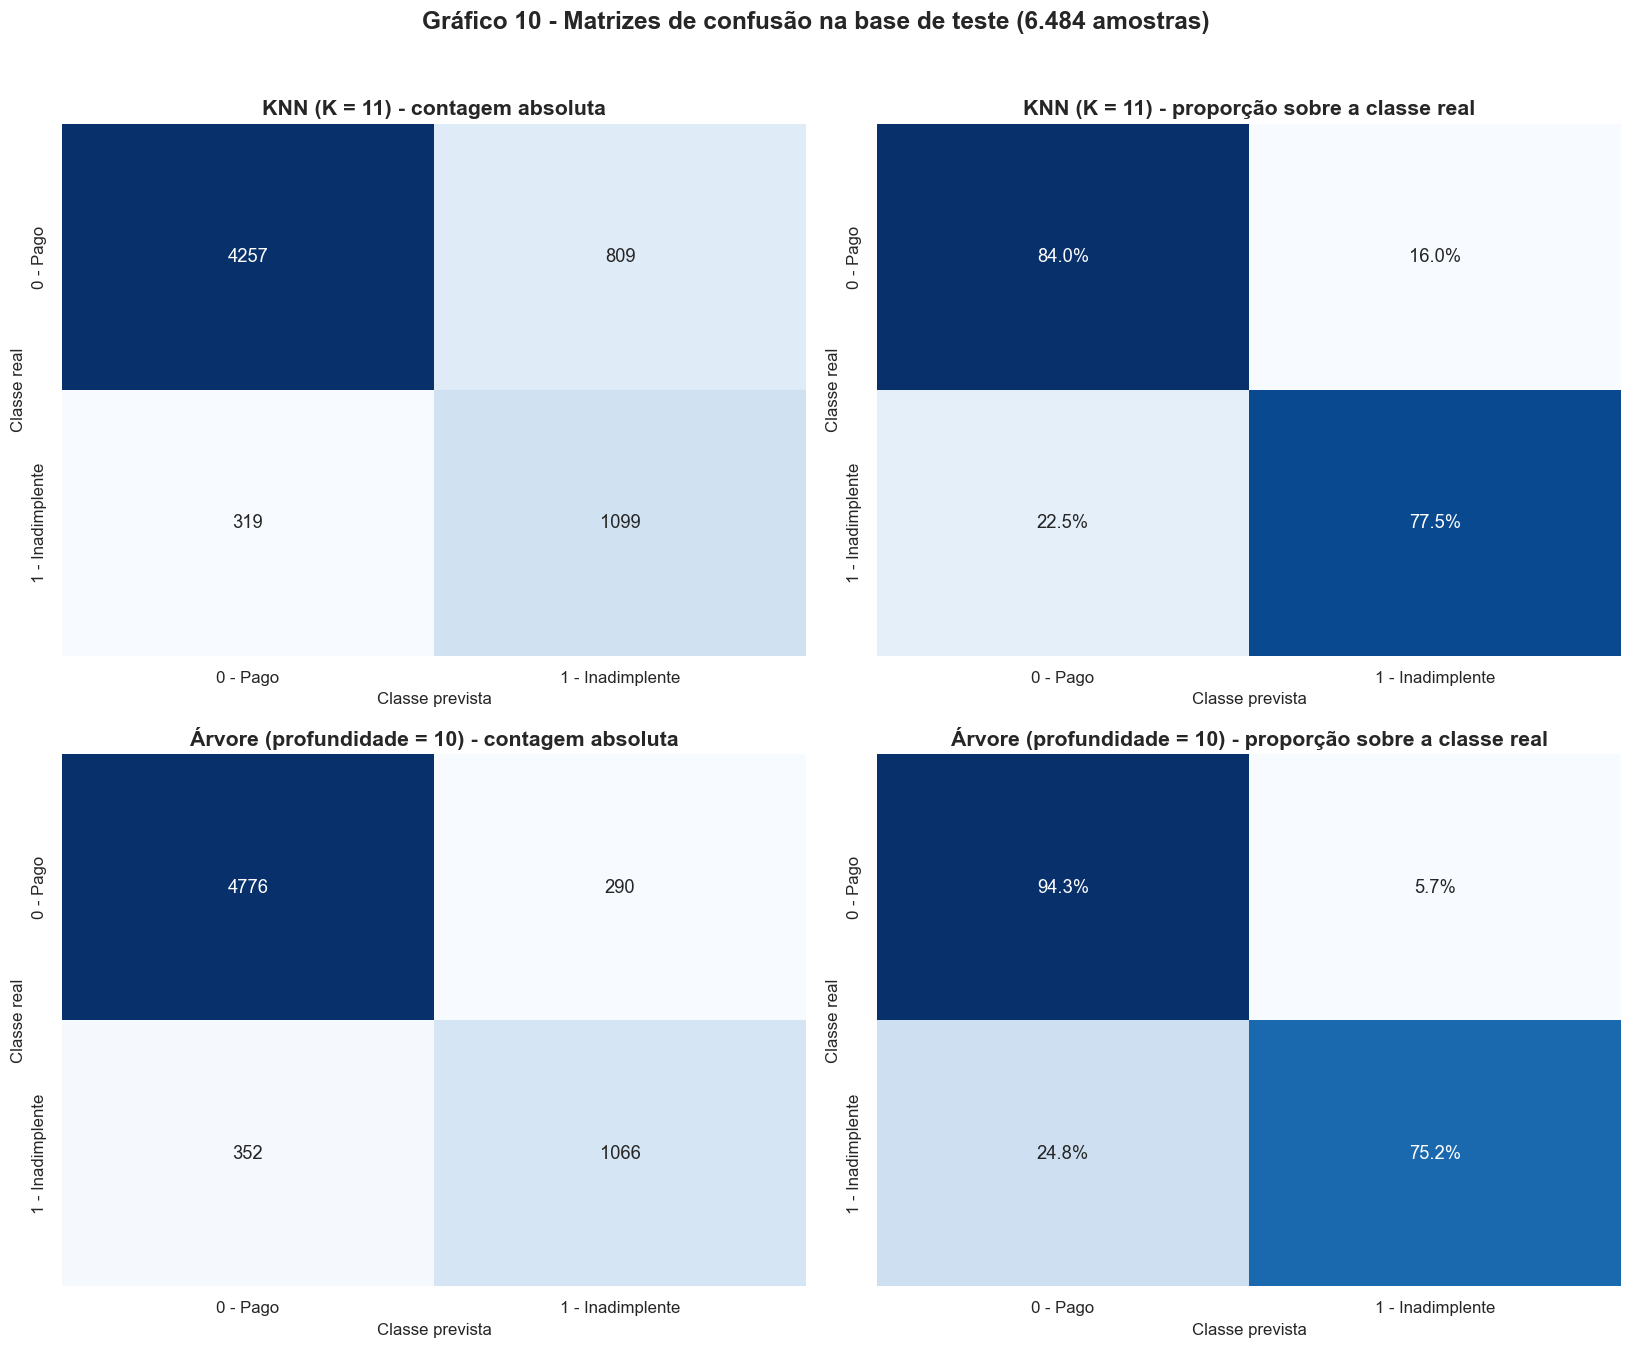

MATRIZES DE CONFUSÃO (BASE DE TESTE)
KNN (K = 11)
    Verdadeiros negativos (pago previsto como pago) : 4.257
    Falsos positivos (pago previsto como inadimplente): 809
    Falsos negativos (inadimplente previsto como pago): 319
    Verdadeiros positivos (inadimplente previsto) ....: 1.099
--------------------------------------------------------------
Árvore (profundidade = 10)
    Verdadeiros negativos (pago previsto como pago) : 4.776
    Falsos positivos (pago previsto como inadimplente): 290
    Falsos negativos (inadimplente previsto como pago): 352
    Verdadeiros positivos (inadimplente previsto) ....: 1.066
--------------------------------------------------------------
O quadrante inferior esquerdo é o Falso Negativo: o modelo liberou um crédito
que não seria pago. É o quadrante crítico desta operação.


In [28]:
# =============================================================================
# MATRIZES DE CONFUSÃO DOS DOIS MODELOS ESCOLHIDOS
# =============================================================================
MODELOS_FINAIS = (
    ('KNN (K = {})'.format(MELHOR_KNN_CONFIG), MELHOR_KNN),
    ('Árvore (profundidade = {})'.format(MELHOR_ARVORE_CONFIG), MELHOR_ARVORE),
)

fig, eixos = plt.subplots(2, 2, figsize=(15, 12))
for linha, (nome_modelo, modelo) in enumerate(MODELOS_FINAIS):
    previsoes = modelo.predict(X_teste)
    matriz = confusion_matrix(y_teste, previsoes)
    normalizada = confusion_matrix(y_teste, previsoes, normalize='true')

    sns.heatmap(
        matriz,
        annot=True,
        fmt='d',
        cmap='Blues',
        cbar=False,
        xticklabels=NOMES_DAS_CLASSES,
        yticklabels=NOMES_DAS_CLASSES,
        ax=eixos[linha][0],
    )
    eixos[linha][0].set_title('{} - contagem absoluta'.format(nome_modelo), fontweight='bold')
    eixos[linha][0].set_xlabel('Classe prevista')
    eixos[linha][0].set_ylabel('Classe real')

    sns.heatmap(
        normalizada,
        annot=True,
        fmt='.1%',
        cmap='Blues',
        cbar=False,
        xticklabels=NOMES_DAS_CLASSES,
        yticklabels=NOMES_DAS_CLASSES,
        ax=eixos[linha][1],
    )
    eixos[linha][1].set_title('{} - proporção sobre a classe real'.format(nome_modelo), fontweight='bold')
    eixos[linha][1].set_xlabel('Classe prevista')
    eixos[linha][1].set_ylabel('Classe real')

fig.suptitle(
    'Gráfico 10 - Matrizes de confusão na base de teste ({} amostras)'.format(padrao_br(len(y_teste))),
    fontsize=16,
    fontweight='bold',
    y=1.02,
)
plt.tight_layout()
plt.show()

print(BAR)
print('MATRIZES DE CONFUSÃO (BASE DE TESTE)')
print(BAR)
for nome_modelo, modelo in MODELOS_FINAIS:
    matriz = confusion_matrix(y_teste, modelo.predict(X_teste))
    verdadeiro_negativo, falso_positivo, falso_negativo, verdadeiro_positivo = matriz.ravel()
    print(nome_modelo)
    print('    Verdadeiros negativos (pago previsto como pago) : {}'.format(padrao_br(verdadeiro_negativo)))
    print('    Falsos positivos (pago previsto como inadimplente): {}'.format(padrao_br(falso_positivo)))
    print('    Falsos negativos (inadimplente previsto como pago): {}'.format(padrao_br(falso_negativo)))
    print('    Verdadeiros positivos (inadimplente previsto) ....: {}'.format(padrao_br(verdadeiro_positivo)))
    print(LIN)
print('O quadrante inferior esquerdo é o Falso Negativo: o modelo liberou um crédito')
print('que não seria pago. É o quadrante crítico desta operação.')
print(BAR)

In [29]:
# =============================================================================
# ANÁLISE FINANCEIRA DOS RESULTADOS DOS MODELOS
# =============================================================================
# Falso Negativo: o modelo libera crédito para quem não paga. Custo: capital perdido.
# Falso Positivo: o modelo recusa quem paga. Custo: margem e relacionamento perdidos.
ALVO_REAL = df.loc[X_teste.index, TARGET]
VALOR_EMPRESTADO = df.loc[X_teste.index, 'loan_amnt']

TAXAS_DE_PERDA = [0.40, 0.60, 0.80, 1.00]
MARGENS_ANUAIS = [0.05, 0.10, 0.15, 0.20]
NOMES_MODELOS = [nome for nome, _ in MODELOS_FINAIS]
EXPOSICAO_INADIMPLENTE = float(VALOR_EMPRESTADO[ALVO_REAL == CLASSE_MINORIA].mean())
CREDITO_ADIMPLENTE = float(VALOR_EMPRESTADO[ALVO_REAL == CLASSE_MAIORIA].mean())

# O falso negativo custa o contrato inteiro, e o falso positivo custa a margem que o
# banco deixaria de ganhar.
ERROS, PERDA_DE_CAPITAL, CREDITO_RECUSADO = {}, {}, {}
for nome_modelo, modelo in MODELOS_FINAIS:
    _, falsos_positivos, falsos_negativos, _ = confusion_matrix(
        ALVO_REAL, modelo.predict(X_teste)).ravel()
    ERROS[nome_modelo] = {'FP': falsos_positivos, 'FN': falsos_negativos}
    PERDA_DE_CAPITAL[nome_modelo] = falsos_negativos * EXPOSICAO_INADIMPLENTE
    CREDITO_RECUSADO[nome_modelo] = falsos_positivos * CREDITO_ADIMPLENTE

    print(nome_modelo)
    print('    {} inadimplentes liberados -> US$ {} de capital em risco'.format(
        padrao_br(falsos_negativos), padrao_br(PERDA_DE_CAPITAL[nome_modelo])))
    print('    {} bons clientes recusados -> US$ {} de crédito barrado'.format(
        padrao_br(falsos_positivos), padrao_br(CREDITO_RECUSADO[nome_modelo])))

# Custo total em cada combinação de taxa de perda e margem. Assumir um par único
# esconderia a decisão dentro de uma suposição invisível.
tabela_veredito = pd.DataFrame([
    {
        'Taxa de perda': taxa,
        'Margem anual': margem,
        **{
            nome: round(PERDA_DE_CAPITAL[nome] * taxa + CREDITO_RECUSADO[nome] * margem, 2)
            for nome in NOMES_MODELOS
        },
    }
    for taxa in TAXAS_DE_PERDA
    for margem in MARGENS_ANUAIS
])
tabela_veredito['Melhor opção'] = tabela_veredito[NOMES_MODELOS].idxmin(axis=1)
vitorias = tabela_veredito['Melhor opção'].value_counts()

print(LIN)
print('--- CUSTO TOTAL POR CENÁRIO (USD) ---')
display(tabela_veredito)
print('{} é mais barata em {} dos {} cenários.'.format(
    vitorias.index[0], padrao_br(vitorias.iloc[0]), padrao_br(len(tabela_veredito))))

# Ponto de equilíbrio: quantas vezes o custo de um default precisa superar a margem
# perdida com um cliente recusado para o modelo de maior recall compensar a troca.
MAIOR_RECALL = min(NOMES_MODELOS, key=lambda nome: ERROS[nome]['FN'])
MENOR_RECALL = max(NOMES_MODELOS, key=lambda nome: ERROS[nome]['FN'])
PONTO_DE_EQUILIBRIO = (
    (ERROS[MAIOR_RECALL]['FP'] - ERROS[MENOR_RECALL]['FP']) * CREDITO_ADIMPLENTE
    / ((ERROS[MENOR_RECALL]['FN'] - ERROS[MAIOR_RECALL]['FN']) * EXPOSICAO_INADIMPLENTE)
)

print('{} evita {} inadimplentes e recusa {} bons clientes a mais que {}.'.format(
    MAIOR_RECALL,
    padrao_br(ERROS[MENOR_RECALL]['FN'] - ERROS[MAIOR_RECALL]['FN']),
    padrao_br(ERROS[MAIOR_RECALL]['FP'] - ERROS[MENOR_RECALL]['FP']),
    MENOR_RECALL))
print('Só compensa se o custo de um default superar {} vezes a margem de um recusado.'.format(
    padrao_br(PONTO_DE_EQUILIBRIO, 2)))
print(BAR)


KNN (K = 11)
    319 inadimplentes liberados -> US$ 3.436.826 de capital em risco
    809 bons clientes recusados -> US$ 7.501.183 de crédito barrado
Árvore (profundidade = 10)
    352 inadimplentes liberados -> US$ 3.792.359 de capital em risco
    290 bons clientes recusados -> US$ 2.688.929 de crédito barrado
--------------------------------------------------------------
--- CUSTO TOTAL POR CENÁRIO (USD) ---


,Taxa de perda,Margem anual,KNN (K = 11),Árvore (profundidade = 10),Melhor opção
0,0.4,0.05,1749789.45,1651390.18,Árvore (profundidade = 10)
1,0.4,0.10,2124848.62,1785836.61,Árvore (profundidade = 10)
2,0.4,0.15,2499907.79,1920283.03,Árvore (profundidade = 10)
3,0.4,0.20,2874966.96,2054729.46,Árvore (profundidade = 10)
4,0.6,0.05,2437154.58,2409862.05,Árvore (profundidade = 10)
5,0.6,0.10,2812213.75,2544308.48,Árvore (profundidade = 10)
6,0.6,0.15,3187272.93,2678754.91,Árvore (profundidade = 10)
7,0.6,0.20,3562332.10,2813201.34,Árvore (profundidade = 10)
8,0.8,0.05,3124519.72,3168333.93,KNN (K = 11)
9,0.8,0.10,3499578.89,3302780.36,Árvore (profundidade = 10)


Árvore (profundidade = 10) é mais barata em 14 dos 16 cenários.
KNN (K = 11) evita 33 inadimplentes e recusa 519 bons clientes a mais que Árvore (profundidade = 10).
Só compensa se o custo de um default superar 13,54 vezes a margem de um recusado.


## Análise de negócio e veredito

### Qual erro é o pior?

Os dois erros têm consequências financeiras opostas:

- **Falso Negativo (FN)** — o modelo prevê "paga" para quem **não** paga. O banco libera o
  crédito e não recebe de volta. Custo: o valor inteiro do contrato.
- **Falso Positivo (FP)** — o modelo prevê "não paga" para quem **paga**. O banco recusa um
  bom cliente. Custo: a margem que deixou de ganhar.

O FN é o erro mais caro, porque custa o contrato inteiro enquanto o FP custa apenas a margem
sobre um cliente que continuaria pagando.

### O conflito real entre os dois modelos

| | KNN (K = 11) | Árvore (profundidade 10) |
|---|---|---|
| Acurácia no teste | 82,60% | **90,10%** |
| Precisão dos inadimplentes | 57,60% | **78,61%** |
| Recall dos inadimplentes | **77,50%** | 75,18% |
| F1 dos inadimplentes | 66,09% | **76,86%** |
| Falsos negativos | **319** | 352 |
| Falsos positivos | 809 | **290** |
| Capital em risco | **US$ 3.436.826** | US$ 3.792.359 |
| Crédito indevidamente recusado | US$ 7.501.183 | **US$ 2.688.929** |

O KNN é melhor em **uma** coisa, e é a mais cara: libera **33 inadimplentes a menos** e, em
troca, recusa **519 clientes bons a mais**.

### O veredito

Para decidir, é preciso um preço para cada erro, portanto foram assumidos valores para as
taxas de perda e de margem. Assim a comparação pode ser feita em 16 cenários combinando taxa
de perda (40% a 100%) e margem anual (5% a 20%).

**Resultado: a Árvore de Decisão é mais barata em 14 dos 16 cenários.**

A Árvore vence quando a perda é baixa **e** a margem é alta, que é a combinação em que a
perda por default deixa de ser assimétrica em relação ao custo de recusar um cliente bom. O
KNN só ganha nos dois cenários mais fechados: perda de 80% ou de 100% contra margem de 5%,
ou seja, um default custando 16 a 20 vezes a margem de um cliente recusado. Mesmo aí a
diferença é de menos de US$ 120 mil, e o limiar geral é mais alto: ele só compensaria se o
custo de um default superasse **13,54 vezes** a margem perdida com um cliente recusado,
relação que não se sustenta em nenhum dos outros 14 cenários simulados.

**Veredito: colocar a Árvore de Decisão em produção**, por três razões:

1. **É mais barata na grande maioria dos cenários** e só perde em recall, e a diferença de
   recall é de 2,32 pontos contra uma economia de US$ 4,8 milhões em crédito barrado.
2. **É explicável.** A decisão sai de uma árvore de corte, e dá para apontar exatamente qual
   regra recusou o pedido. Um KNN que pondera 11 vizinhos não permite explicar a decisão.
3. **É mais barata de operar.** O KNN precisa de padronização, guarda a base de treino
   inteira e faz 11 comparações de distância por cliente; a árvore percorre no máximo 10 cortes.

### Contrapontos ao modelo escolhido

- **A Árvore ainda erra demais do lado perigoso.** Com recall de 75,18%, deixa passar 352 dos
  1.418 inadimplentes da carteira de teste. Esse é o ponto fraco real da solução.
- **A redundância da coluna calculada pesa mais no KNN.** `comprometimento_renda` duplica
  `loan_percent_income` com correlação de 0,9989, então o mesmo sinal entra duas vezes na
  distância euclidiana. Isso ajuda a explicar por que o KNN tem precisão de apenas 57,60%
  em uma base majoritariamente de bons pagadores.